# Mounting the drive
- The unzipped image files have been uploaded to a folder named Data/Data-Mini-Project.   
- The unzipped csv file (containing additional information) is also uploaded to Data/Data-Mini-Project.   
- The data has been taken from a publicly available resource:
https://www.kaggle.com/datasets/akshayramakrishnan28/fracture-classification-dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Importing the modules and setting the seed

In [ ]:
import os
import random
random.seed(27)
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import pickle
from sklearn.model_selection import StratifiedKFold, train_test_split
from tensorflow.keras import layers, models, Input, regularizers
import tensorflow.keras.utils as utils
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
import concurrent.futures
from tqdm import tqdm
from prettytable import PrettyTable

# Creating and Reading the tfrecord files


### Listing the x-ray image files
- The x-ray images containing fractures are stored under the "/Fractured" folder.
- The x-ray images containing no fractures are stored under the "/Non_fractured" folder.
- We are creating a list of all the image file paths from both these folders.

In [ ]:
# Declaring the path
dataset_path = "/content/drive/MyDrive/Data/Data-Mini-Project"
# Creating a list of all the fractured image files with their entire path
dataset_path_fractured = os.path.join(dataset_path, "Fractured")
file_list_fractured = [os.path.join(dataset_path_fractured, file_i) for file_i in os.listdir(dataset_path_fractured)]
# Creating a list of all the non-fractured image files with their entire path
dataset_path_non_fractured = os.path.join(dataset_path, "Non_fractured")
file_list_non_fractured = [os.path.join(dataset_path_non_fractured, file_i) for file_i in os.listdir(dataset_path_non_fractured)]
# Combining and creating a list of all image files with their entire path
file_list = file_list_fractured + file_list_non_fractured
# Function to extract the numeric part from the filename
def extract_file_number(file_path):
  # Extract just the filename
  filename = os.path.basename(file_path)
  # Remove 'IMG' prefix and '.jpg' extension, then convert to int
  return int(filename[3:-4])
# Sort the file list using the extracted number
file_list_sorted = sorted(file_list, key=extract_file_number)
print("List of all the files")
print(file_list_sorted)
print("Number of files")
print(len(file_list_sorted))

List of all the files
['/content/drive/MyDrive/Data/Data-Mini-Project/Non_fractured/IMG0000000.jpg', '/content/drive/MyDrive/Data/Data-Mini-Project/Non_fractured/IMG0000001.jpg', '/content/drive/MyDrive/Data/Data-Mini-Project/Non_fractured/IMG0000002.jpg', '/content/drive/MyDrive/Data/Data-Mini-Project/Non_fractured/IMG0000003.jpg', '/content/drive/MyDrive/Data/Data-Mini-Project/Non_fractured/IMG0000004.jpg', '/content/drive/MyDrive/Data/Data-Mini-Project/Non_fractured/IMG0000005.jpg', '/content/drive/MyDrive/Data/Data-Mini-Project/Non_fractured/IMG0000006.jpg', '/content/drive/MyDrive/Data/Data-Mini-Project/Non_fractured/IMG0000007.jpg', '/content/drive/MyDrive/Data/Data-Mini-Project/Non_fractured/IMG0000008.jpg', '/content/drive/MyDrive/Data/Data-Mini-Project/Non_fractured/IMG0000009.jpg', '/content/drive/MyDrive/Data/Data-Mini-Project/Non_fractured/IMG0000010.jpg', '/content/drive/MyDrive/Data/Data-Mini-Project/Non_fractured/IMG0000011.jpg', '/content/drive/MyDrive/Data/Data-Mini-Pr

### X-ray image data shape analysis

In [ ]:
def image_shapes(file_list):
    for image_file in file_list:
        # Reading the image file
        image_data = tf.io.read_file(image_file)
        # Decoding the JPEG image into a tensor with 3 channels
        image = tf.io.decode_jpeg(image_data, channels=3)
        # Printing the filename and its shape
        print(f"{os.path.basename(image_file)} shape: {image.shape}")
image_shapes(random.sample(file_list_sorted,20))

IMG0003769.jpg shape: (373, 454, 3)
IMG0000993.jpg shape: (373, 454, 3)
IMG0002037.jpg shape: (454, 373, 3)
IMG0003401.jpg shape: (454, 373, 3)
IMG0000293.jpg shape: (373, 454, 3)
IMG0003023.jpg shape: (454, 373, 3)
IMG0003802.jpg shape: (454, 373, 3)
IMG0002644.jpg shape: (373, 454, 3)
IMG0002378.jpg shape: (2140, 1760, 3)
IMG0002712.jpg shape: (454, 373, 3)
IMG0000323.jpg shape: (373, 454, 3)
IMG0002532.jpg shape: (454, 373, 3)
IMG0003473.jpg shape: (373, 454, 3)
IMG0001762.jpg shape: (454, 373, 3)
IMG0003207.jpg shape: (454, 373, 3)
IMG0001731.jpg shape: (454, 373, 3)
IMG0003065.jpg shape: (454, 373, 3)
IMG0000215.jpg shape: (2304, 2880, 3)
IMG0002727.jpg shape: (454, 373, 3)
IMG0001822.jpg shape: (454, 373, 3)


As we can see, the X-ray images have varying dimentions but for model training and evaluation, it is essential to standardize these images by resizing them to a fixed dimension (224 x 224).

Additionally, the images have 3-channels per pixel but x-rays contain greyscale information (a focus on structure and not color). Therefore, we convert the images to a single-channel grayscale format.

These changes ensure consistency in image dimensions and reduces computational intensity by eliminating redundant color channels while preserving the diagnostic features.

### Additional data explanation

Now that we have a list of all the image file paths, we map every file with the CSV file to access additional information about each image. The CSV file contains the following variables, which are explained below:

- `hand`, `leg`, `hip`, `shoulder` :  
  These binary variables indicate which body part(s) are visible in the X-ray. A value of 1 means that the corresponding body part is involved, while 0 means it is not.
- `mixed` :  
  If the variable is set to 0, then exactly one of the body part variables (hand, leg, hip, or shoulder) will be marked as 1. If the variable is set to 1, then more than one of these body part variables will be marked as 1, indicating that the image includes multiple body parts.
- `fracture` :  
  This binary variable indicates whether a fracture is present represented by 1 or not present represented by 0.  
- `fracture_count` :  
  This variable provides the number of fractures detected in the image. If there is no fracture then the count is set to 0. If these is a fracture then the value can be an integer, (1, 2, 3, ...).
- `frontal`, `lateral`, `oblique` :  
  These binary variables indicate the scan angles used in the X-ray. A value of 1 means that the corresponding angle is present, while 0 means it is not.
- `multiscan` :  
  This variable signifies that more than one scan angle is taken. It is determined by checking if more than one of the scan angle variables (frontal, lateral, oblique) is marked as 1.
- `hardware`:
  This binary variable indicates whether any foreign hardware (such as screws, plates, etc.) is visible in the X-ray. If any such thing is visible it is represented by 1 and if not, it is represented by 0.


In order to encode all this information in an optimal manner, we use categorical representation for some of these variables and exclude redundant variables. The variable descriptions are as follows:

- `image_raw` :  
The raw image data, read directly from the image file.
- `body_part` :  
Represents the body part(s) visible in the X-ray. Instead of using separate binary flags for each body part, a single integer encodes the combination. The mapping is as follows:  
{
    1: "Shoulder",
    2: "Hip",
    3: "Hip and Shoulder",
    4: "Leg",
    5: "Leg and Shoulder",
    6: "Leg and Hip",
    7: "Leg, Hip, and Shoulder",
    8: "Hand",
    9: "Hand and Shoulder",
    10: "Hand and Hip",
    11: "Hand, Hip, and Shoulder",
    12: "Hand and Leg",
    13: "Hand, Leg, and Shoulder",
    14: "Hand, Leg, and Hip",
    15: "All (Hand, Leg, Hip, and Shoulder)"
}
- `angles` :  
Represents the scan angle(s) used to capture the X-ray. Instead of using separate binary flags for each angle, a single integer encodes the combination. The mapping is as follows:  
{
    1: "Oblique",
    2: "Lateral",
    3: "Lateral and Oblique",
    4: "Frontal",
    5: "Frontal and Oblique",
    6: "Frontal and Lateral",
    7: "Frontal, Lateral, and Oblique"
}
- `hardware` :  
Indicates whether any foreign material (such as screws, plates, or implants) is visible in the X-ray.  0 if any hardware is present and 1 if there is.
- `fracture` (Target) :    
Indicates whether a fracture is present in the X-ray.  0 if these is no fracture and 1 if there is a fracture.

Variables, `mixed` and `multiscan` are now redundant, as their information is already captured within body_part and angles, respectively. Lastly, variable `fracture_count` is also ignored as we are developing a classifier to detect only the presence or absence of a fracture, not the exact number of fractures. This variable may be considered in future iterations if we extend the model's functionality.

### Generating the tfrecord files

In [ ]:
# Loading the dataset containing the additional information
df = pd.read_csv("/content/drive/MyDrive/Data/Data-Mini-Project/Additional_Data.csv")
# Setting the path to save the TFRecord files
tfrecords_dir = "/content/drive/MyDrive/Data/Data-Mini-Project/TFRecords"
# Ensuring that the TFRecords directory exists
os.makedirs(tfrecords_dir, exist_ok=True)

# Generating the test set using a stratified (to handle the class imbalance) split (20% holdout)
train_val_df, test_df = train_test_split(df, test_size=0.2, shuffle=True, stratify=df['fractured'], random_state=27)
# Splitting the data into 5 stratified (to handle the class imbalance) folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=27)
split_files = skf.split(train_val_df, train_val_df['fractured'])

# Creating a function to generate a tfrecord example
def create_tfrecord(df_file_record):
  # Extracting the variables
  hand = df_file_record['hand']
  leg = df_file_record['leg']
  hip = df_file_record['hip']
  shoulder = df_file_record['shoulder']
  frontal = df_file_record['frontal']
  lateral = df_file_record['lateral']
  oblique = df_file_record['oblique']
  hardware = df_file_record['hardware']
  file_name = df_file_record['image_id']
  fractured = df_file_record['fractured']
  # Converting the hand, leg, hip and shoulder binary variables into a single categorial variable
  body_part = (hand * 8) + (leg * 4) + (hip * 2) + (shoulder * 1)
  # Converting the frontal, lateral and oblique binary variables into a single categorical variable
  angles = (frontal * 4) + (lateral * 2) + (oblique * 1)
  # Extracting the image file path
  if fractured:
    image_file_path = os.path.join(dataset_path, "Fractured", file_name)
  else:
    image_file_path = os.path.join(dataset_path, "Non_fractured", file_name)
  # Reading the image
  img_cv = cv2.imread(image_file_path, cv2.IMREAD_COLOR)
  # Converting from BGR to RGB
  img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
  # Converting the image to a grayscale image (single band)
  img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
  # Resizing the image to (224 x 224) for consistency
  img_resized = cv2.resize(img_gray, (224, 224))
  # Converting the image to a tensor and adding the channel dimension (224,224,1)
  image_tensor = tf.convert_to_tensor(img_resized, dtype=tf.uint8)
  image_tensor = tf.expand_dims(image_tensor, axis=-1)
  # Encoding the image as JPEG bytes
  image_bytes = tf.io.encode_jpeg(image_tensor).numpy()
  # Creating a dictionary of the features
  feature = {
      "image_raw": tf.train.Feature(bytes_list=tf.train.BytesList(value=[image_bytes])),
      "body_part": tf.train.Feature(int64_list=tf.train.Int64List(value=[body_part])),
      "angles": tf.train.Feature(int64_list=tf.train.Int64List(value=[angles])),
      "hardware": tf.train.Feature(int64_list=tf.train.Int64List(value=[hardware])),
      "fractured": tf.train.Feature(int64_list=tf.train.Int64List(value=[fractured])),
  }
  # Creating a TFRecord Example
  example = tf.train.Example(features=tf.train.Features(feature=feature))
  # Serializing the example to a byte string
  return example.SerializeToString()

# Generate TFRecords for 5-Fold Cross-Validation
for fold, (train_idx, val_idx) in enumerate(split_files):
  # Extracting the training and validation splits for a particular fold
  train_fold = train_val_df.iloc[train_idx]
  val_fold = train_val_df.iloc[val_idx]
  # Setting the path to store the training and validation tfrecord files of a particular fold
  train_tfrecord_path = os.path.join(tfrecords_dir, f"train_fold_{fold}.tfrecord")
  val_tfrecord_path = os.path.join(tfrecords_dir, f"val_fold_{fold}.tfrecord")
  # For the training data of a particular fold
  print(f"Processing fold {fold} with training data having {train_fold.shape[0]} files.")
  # Writing the training tfrecords for a particular fold
  with tf.io.TFRecordWriter(train_tfrecord_path) as writer:
    # Initiating the parallel process executor
    with concurrent.futures.ThreadPoolExecutor() as executor:
      # For every training file in a particular fold
      # Converting each file into a tfrecord example parallelly
      for training_file in tqdm(
          filter(None, executor.map(create_tfrecord, [row for _, row in train_fold.iterrows()])),
          total=train_fold.shape[0],
          desc=f"Fold {fold}"
      ):
        # Aggregating all the tfrecord examples for each training file in a particular fold and storing it in a tfrecord training file for that fold
        writer.write(training_file)
  # For the validation data of a particular fold
  print(f"Processing fold {fold} with validation data having {val_fold.shape[0]} files.")
  # Writing the validation tfrecords for a particular fold
  with tf.io.TFRecordWriter(val_tfrecord_path) as writer:
    # Initiating the parallel process executor
    with concurrent.futures.ThreadPoolExecutor() as executor:
      # For every validation file in a particular fold
      # Converting each file into a tfrecord example parallelly
      for validation_file in tqdm(
          executor.map(create_tfrecord, [row for _, row in val_fold.iterrows()]),
          total=val_fold.shape[0],
          desc=f"Fold {fold}"
      ):
        # Aggregating all the tfrecord examples for each validation file in a particular fold and storing it in a tfrecord validation file for that fold
        writer.write(validation_file)

# Setting the path to store the testing tfrecord files
test_tfrecord_path = os.path.join(tfrecords_dir, "test.tfrecord")
# For the testing data
print(f"Processing testing data having {test_df.shape[0]} files.")
# Writing the testing tfrecords
with tf.io.TFRecordWriter(test_tfrecord_path) as writer:
  # Initiating the parallel process executor
  with concurrent.futures.ThreadPoolExecutor() as executor:
    # For every testing file
    # Converting each file into a tfrecord example parallelly
    for test_file in tqdm(
        executor.map(create_tfrecord, [row for _, row in test_df.iterrows()]),
        total=test_df.shape[0],
        desc="Test"
    ):
      # Aggregating all the tfrecord examples for each test file and storing it in a tfrecord test file
      writer.write(test_file)
print("\nTFRecord file generation completed.")

Processing fold 0 with training data having 2612 files.


Fold 0: 100%|██████████| 2612/2612 [01:22<00:00, 31.54it/s]


Processing fold 0 with validation data having 654 files.


Fold 0: 100%|██████████| 654/654 [00:10<00:00, 64.77it/s]


Processing fold 1 with training data having 2613 files.


...

Processing fold 4 with validation data having 653 files.


Fold 4: 100%|██████████| 653/653 [00:07<00:00, 92.04it/s] 


Processing testing data having 817 files.


Test: 100%|██████████| 817/817 [00:11<00:00, 69.46it/s]



TFRecord file generation completed.


### Reading the tfrecord files

In [ ]:
def augment(features, label):
    # Extracting the image from features/attributes
    image = features["image_raw"]
    # Appling horizontal and vertical flips at random
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    # Appling rotationsat 0, 90, 180, or 270 degrees at random
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    # Updating the features with the augmented image
    features["image_raw"] = image
    # Returning the modified features and the unchanged label
    return features, label

# Defining a function to convert one TFRecord example into a set of attributes and target tensors
def parse_tfrecord(example):
    # Defining the expected feature structure
    feature_description = {
    "image_raw": tf.io.FixedLenFeature([], tf.string),
    "body_part": tf.io.FixedLenFeature([], tf.int64),
    "angles": tf.io.FixedLenFeature([], tf.int64),
    "hardware": tf.io.FixedLenFeature([], tf.int64),
    "fractured": tf.io.FixedLenFeature([], tf.int64),
    }
    # Parsing the TFRecord example with the defined feature structure
    parsed = tf.io.parse_single_example(example, feature_description)
    # Decoding the image data
    image = tf.io.decode_jpeg(parsed["image_raw"], channels=1)
    # Resize the image to a fixed shape
    image = tf.image.resize(image, [224, 224])
    # Stacking the tabular features (body_part, angles, hardware) into a vector
    tabular_input = tf.stack([
        tf.cast(parsed["body_part"], tf.float32),
        tf.cast(parsed["angles"], tf.float32),
        tf.cast(parsed["hardware"], tf.float32)
    ])
    # Extracting the remaining variables as features
    features = {
        "image_raw": image,
        "tabular_input": tabular_input
    }
    # Extracting the target variable, fractured
    label = tf.cast(parsed["fractured"], tf.float32)
    return features, label

# Defining a function to convert the TFRecord file to a dataset
def load_tfrecord_dataset(tfrecord_path, augment_data=False):
    # Creating the dataset from the tfrecord file
    dataset = tf.data.TFRecordDataset(tfrecord_path)
    # Parsing example using the aforementioned parsing function in an optimized manner
    dataset = dataset.map(parse_tfrecord, num_parallel_calls=tf.data.AUTOTUNE)
    # If the augmentation flag is get then we augment the data in an optimized manner
    if augment_data:
        dataset = dataset.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    # Batching the data in a group of 32,
    # Shuffling the data so as to reduce bias,
    # Prefetching the data for the next batch to optimize performance
    dataset = dataset.batch(32).shuffle(1000).prefetch(tf.data.AUTOTUNE)
    # Returning the dataset
    return dataset

In [ ]:
train_fold_0 = load_tfrecord_dataset("/content/drive/MyDrive/Data/Data-Mini-Project/TFRecords/train_fold_0.tfrecord", augment_data=True)
val_fold_0 = load_tfrecord_dataset("/content/drive/MyDrive/Data/Data-Mini-Project/TFRecords/val_fold_0.tfrecord")
train_fold_1 = load_tfrecord_dataset("/content/drive/MyDrive/Data/Data-Mini-Project/TFRecords/train_fold_1.tfrecord", augment_data=True)
val_fold_1 = load_tfrecord_dataset("/content/drive/MyDrive/Data/Data-Mini-Project/TFRecords/val_fold_1.tfrecord")
train_fold_2 = load_tfrecord_dataset("/content/drive/MyDrive/Data/Data-Mini-Project/TFRecords/train_fold_2.tfrecord", augment_data=True)
val_fold_2 = load_tfrecord_dataset("/content/drive/MyDrive/Data/Data-Mini-Project/TFRecords/val_fold_2.tfrecord")
train_fold_3 = load_tfrecord_dataset("/content/drive/MyDrive/Data/Data-Mini-Project/TFRecords/train_fold_3.tfrecord", augment_data=True)
val_fold_3 = load_tfrecord_dataset("/content/drive/MyDrive/Data/Data-Mini-Project/TFRecords/val_fold_3.tfrecord")
train_fold_4 = load_tfrecord_dataset("/content/drive/MyDrive/Data/Data-Mini-Project/TFRecords/train_fold_4.tfrecord", augment_data=True)
val_fold_4 = load_tfrecord_dataset("/content/drive/MyDrive/Data/Data-Mini-Project/TFRecords/val_fold_4.tfrecord")
fold_data = [(train_fold_0, val_fold_0),
             (train_fold_1, val_fold_1),
             (train_fold_2, val_fold_2),
             (train_fold_3, val_fold_3),
             (train_fold_4, val_fold_4),]
test = load_tfrecord_dataset("/content/drive/MyDrive/Data/Data-Mini-Project/TFRecords/test.tfrecord")

# Creating and testing a simple model

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1605632)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │       1,605,633 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,605,953 (6.13 MB)

 Trainable params: 1,605,953 (6.13 MB)

 Non-trainable params: 0 (0.00 B)

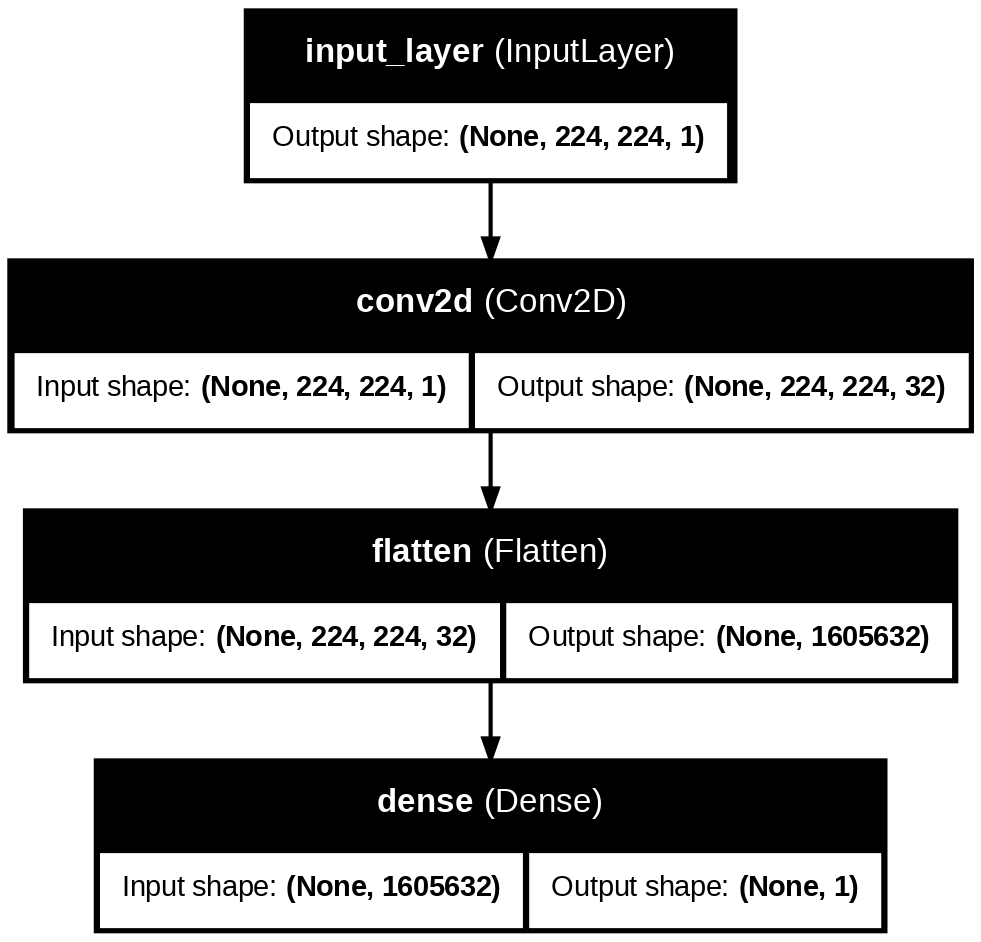

In [ ]:
def simple_model_structure():
    # Defining the input layer with a shape of (224, 224, 1)
    image_input = Input(shape=(224, 224, 1))
    # Convolution layer: 32 filters, 3x3 kernel, ReLU activation, same padding
    x = layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same')(image_input)
    # Flattening the output of the convolutional layer
    x = layers.Flatten()(x)
    # Output layer: 1 neuron with sigmoid activation to make binary classifications
    outputs = layers.Dense(1, activation='sigmoid')(x)
    # Returning the built model
    return models.Model(inputs=image_input, outputs=outputs)

# Initializing the model
simple_model = simple_model_structure()
# Displaying the model architecture, including layer names, output shapes, and parameter counts
simple_model.summary()
# Plotting the model structure with input/output shapes for visualization
utils.plot_model(simple_model, to_file="simple_model_structure.png", show_shapes=True, show_layer_names=True, dpi=150)

In [ ]:
# Ensuring that the Fold directory exists
os.makedirs('/content/drive/MyDrive/Data/Data-Mini-Project/Fold/Simple', exist_ok=True)

def fold_train_evaluation(fold,train_fold,val_fold):
  # Initializing the model
  simple_model = simple_model_structure()
  # Using a loss function that handles class imbalance like BinaryCrossentropy
  loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=False)
  # Compiling the model with appropriate loss function and optimizer
  simple_model.compile(optimizer="adam", loss=loss_fn, metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
  # Checkpoint callback to save the best model during training
  checkpoint_cb = ModelCheckpoint("/content/drive/MyDrive/Data/Data-Mini-Project/Fold/Simple/simple_model_fold-"+str(fold)+".h5", save_best_only=True, monitor='val_auc', mode='max')
  # Early stopping callback to stop training if validation loss does not improve for 5 epochs
  early_stopping_cb = EarlyStopping(patience=5, restore_best_weights=True, monitor='val_auc')
  # Training the model
  train_fold = train_fold.map(lambda features, label: (features["image_raw"], label))
  val_fold = val_fold.map(lambda features, label: (features["image_raw"], label))
  simple_model_history = simple_model.fit(train_fold, validation_data=val_fold, epochs=30, callbacks=[checkpoint_cb, early_stopping_cb], class_weight = {0: 1.0, 1: (3366 / 717)})
  simple_model_history = simple_model_history.history
  # Storing the history in the pickle file
  with open('/content/drive/MyDrive/Data/Data-Mini-Project/Fold/Simple/simple_model_history_fold-'+str(fold)+'.pkl', 'wb') as f:
    pickle.dump(simple_model_history, f)

# Generating the model for every fold
for fold in range(5):
  print(f"Fold {fold}")
  fold_train_evaluation(fold,fold_data[fold][0],fold_data[fold][1])

Fold 0
Epoch 1/30
     79/Unknown 16s 55ms/step - accuracy: 0.5272 - auc: 0.5217 - loss: 977.1086 

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


82/82 ━━━━━━━━━━━━━━━━━━━━ 21s 121ms/step - accuracy: 0.5268 - auc: 0.5219 - loss: 951.6135 - val_accuracy: 0.3807 - val_auc: 0.5559 - val_loss: 12.7822
Epoch 2/30
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5788 - auc: 0.6104 - loss: 8.7772

82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.5787 - auc: 0.6101 - loss: 8.7569 - val_accuracy: 0.7034 - val_auc: 0.6061 - val_loss: 2.7170
Epoch 3/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6013 - auc: 0.6006 - loss: 5.8383 - val_accuracy: 0.3823 - val_auc: 0.5631 - val_loss: 4.9676
Epoch 4/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - accuracy: 0.6171 - auc: 0.6362 - loss: 4.8039 - val_accuracy: 0.6789 - val_auc: 0.5528 - val_loss: 2.3666
Epoch 5/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6065 - auc: 0.6428 - loss: 3.8743 - val_accuracy: 0.6254 - val_auc: 0.5556 - val_loss: 1.9114
Epoch 6/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.6763 - auc: 0.7260 - loss: 2.9908 - val_accuracy: 0.7446 - val_auc: 0.5412 - val_loss: 1.3585
Epoch 7/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.6453 - auc: 0.6623 - loss: 3.1675 - val_accuracy: 0.7034 - val_auc: 0.5496 - val_loss: 1.5863
Fold 1
Epoch 1/30
     80/Unknown 8s 52ms/step - accurac

82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 105ms/step - accuracy: 0.5165 - auc: 0.5156 - loss: 1490.6459 - val_accuracy: 0.6600 - val_auc: 0.5425 - val_loss: 8.5644
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6046 - auc: 0.5532 - loss: 16.7415

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6147 - auc: 0.6571 - loss: 3.5703 - val_accuracy: 0.5299 - val_auc: 0.6954 - val_loss: 2.5214
Epoch 5/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.6160 - auc: 0.6820 - loss: 3.0536 - val_accuracy: 0.7458 - val_auc: 0.6859 - val_loss: 1.4314
Epoch 6/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.6379 - auc: 0.6894 - loss: 2.4551 - val_accuracy: 0.6769 - val_auc: 0.6756 - val_loss: 1.4495
Epoch 7/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.6983 - auc: 0.7146 - loss: 2.1240 - val_accuracy: 0.5911 - val_auc: 0.6464 - val_loss: 1.4887
Epoch 8/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.6745 - auc: 0.7392 - loss: 1.7901 - val_accuracy: 0.7504 - val_auc: 0.6749 - val_loss: 1.0106
Epoch 9/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.7271 - auc: 0.7946 - loss: 1.3684 - val_accuracy: 0.6891 - val_auc: 0.6687 - val_loss: 1.0397
Fold 3
Epoch 1/30
     79/Unknown 5s 20ms/step - accura

82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.5207 - auc: 0.5113 - loss: 256.4657 - val_accuracy: 0.3783 - val_auc: 0.6248 - val_loss: 10.7333
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.5916 - auc: 0.6074 - loss: 7.7833 - val_accuracy: 0.6769 - val_auc: 0.5872 - val_loss: 3.0327
Epoch 3/30
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6189 - auc: 0.6724 - loss: 4.5703

82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.6186 - auc: 0.6722 - loss: 4.5702 - val_accuracy: 0.6263 - val_auc: 0.6696 - val_loss: 3.4752
Epoch 4/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6281 - auc: 0.6671 - loss: 4.4172 - val_accuracy: 0.4793 - val_auc: 0.6222 - val_loss: 3.5389
Epoch 5/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.6360 - auc: 0.6858 - loss: 3.3291 - val_accuracy: 0.5789 - val_auc: 0.6090 - val_loss: 2.4038
Epoch 6/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6387 - auc: 0.6941 - loss: 2.8952 - val_accuracy: 0.6156 - val_auc: 0.6150 - val_loss: 2.0462
Epoch 7/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6652 - auc: 0.7462 - loss: 2.4103 - val_accuracy: 0.7596 - val_auc: 0.6520 - val_loss: 1.5455
Epoch 8/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.6680 - auc: 0.7316 - loss: 2.2593 - val_accuracy: 0.4012 - val_auc: 0.6044 - val_loss: 2.6495
Fold 4
Epoch 1/30
     82/Unknown 7s 20ms/step - accurac

82/82 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.5323 - auc: 0.5271 - loss: 955.9063 - val_accuracy: 0.6922 - val_auc: 0.5894 - val_loss: 20.1981
Epoch 2/30
80/82 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5989 - auc: 0.5819 - loss: 32.0605

82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5985 - auc: 0.5825 - loss: 31.5197 - val_accuracy: 0.6371 - val_auc: 0.6493 - val_loss: 3.6180
Epoch 3/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5839 - auc: 0.6353 - loss: 4.2134 - val_accuracy: 0.6922 - val_auc: 0.6167 - val_loss: 2.1175
Epoch 4/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6510 - auc: 0.6674 - loss: 2.7782 - val_accuracy: 0.5605 - val_auc: 0.6445 - val_loss: 2.1928
Epoch 5/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.6679 - auc: 0.6953 - loss: 2.5572 - val_accuracy: 0.4319 - val_auc: 0.6082 - val_loss: 2.5695
Epoch 6/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.6327 - auc: 0.6942 - loss: 2.4744 - val_accuracy: 0.7473 - val_auc: 0.6234 - val_loss: 1.2276
Epoch 7/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.6624 - auc: 0.7196 - loss: 1.8100 - val_accuracy: 0.3155 - val_auc: 0.5675 - val_loss: 3.1660


In [ ]:
roc_auc_values=[]
# For each model
for fold in range(5):
  # Loading the models
  with open('/content/drive/MyDrive/Data/Data-Mini-Project/Fold/Simple/simple_model_history_fold-'+str(fold)+'.pkl', 'rb') as f:
    simple_model_history = pickle.load(f)
  # Extracting the selected model's roc auc
  roc_auc = max(simple_model_history['val_auc'])
  roc_auc_values.append(roc_auc)
  print(f"Fold {fold} ROC AUC: {roc_auc}")

# Selecting the model having the highest roc auc
best_model_index = roc_auc_values.index(max(roc_auc_values))
print(f"Best Model: Fold {best_model_index}")
# Loading the best model
simple_model = tf.keras.models.load_model("/content/drive/MyDrive/Data/Data-Mini-Project/Fold/Simple/simple_model_fold-"+str(best_model_index)+".h5")
# Loading the best model history
with open('/content/drive/MyDrive/Data/Data-Mini-Project/Fold/Simple/simple_model_history_fold-'+str(best_model_index)+'.pkl', 'rb') as f:
  simple_model_history = pickle.load(f)

Fold 0 ROC AUC: 0.6061064004898071
Fold 1 ROC AUC: 0.6995818018913269
Fold 2 ROC AUC: 0.695353090763092
Fold 3 ROC AUC: 0.6696380376815796
Fold 4 ROC AUC: 0.6492726802825928
Best Model: Fold 1


In [ ]:
test_img = test.map(lambda features, label: (features["image_raw"], label))
test_loss, test_accuracy, test_auc = simple_model.evaluate(test_img)
print(f"Fold {fold} - Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, Test AUC: {test_auc:.4f}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 243ms/step - accuracy: 0.6039 - auc: 0.6822 - loss: 2.0135
Fold 4 - Test Loss: 2.1832, Test Accuracy: 0.6095, Test AUC: 0.6847


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


# Creating and testing a deep model

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 100352)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      12,845,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,946,177 (49.39 MB)

 Trainable params: 12,946,177 (49.39 MB)

 Non-trainable params: 0 (0.00 B)

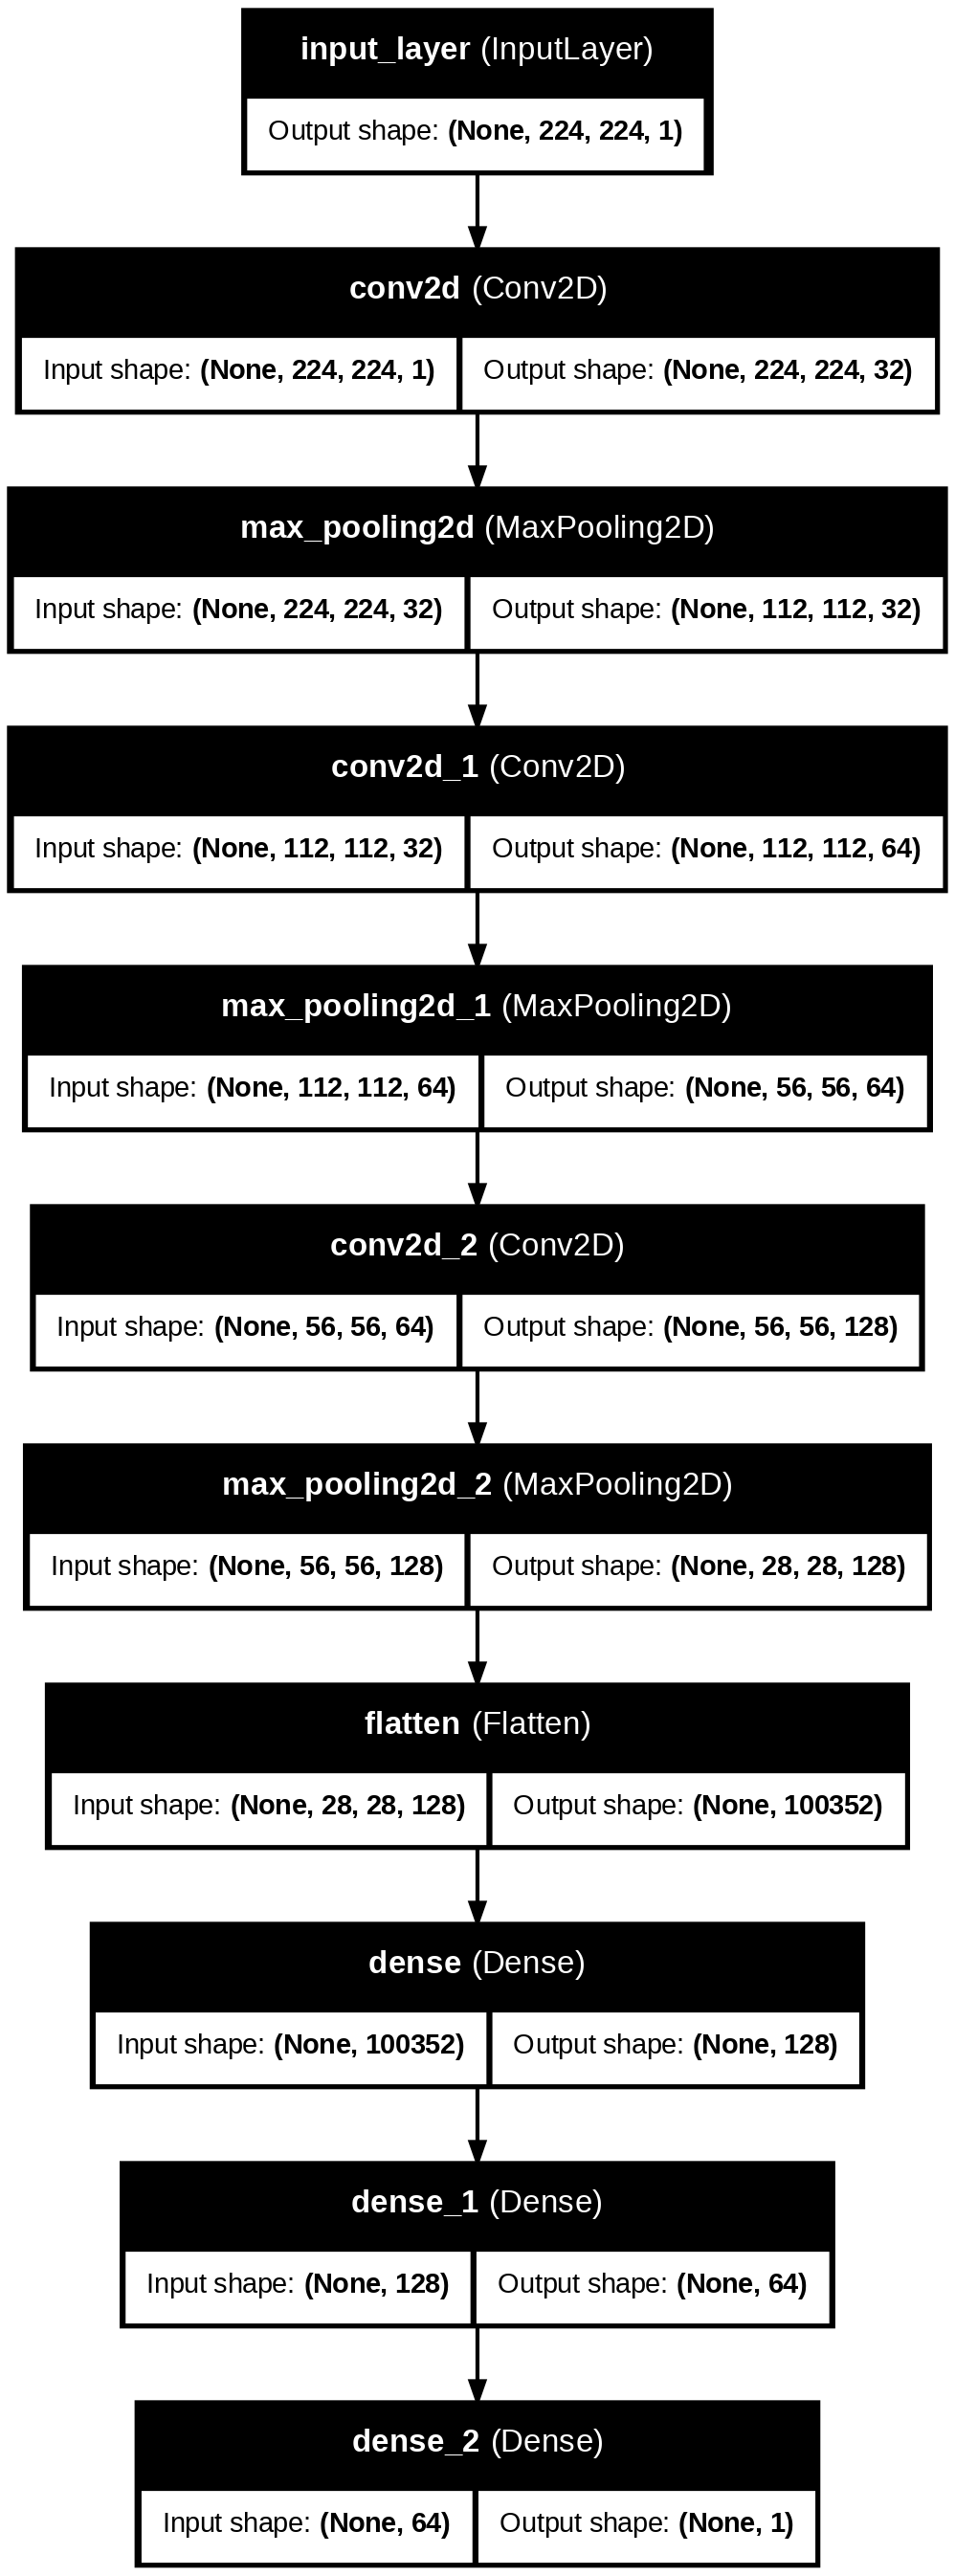

In [ ]:
def deep_model_structure():
    # Defining the input layer with a shape of (224, 224, 1)
    image_input = Input(shape=(224, 224, 1))
    # Convolution layer: 32 filters, 3x3 kernel, ReLU activation, same padding
    x = layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same')(image_input)
    # Max pooling: pool size 2x2
    x = layers.MaxPooling2D((2, 2))(x)
    # Convolution layer: 64 filters, 3x3 kernel, ReLU activation, same padding
    x = layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same')(x)
    # Max pooling: pool size 2x2
    x = layers.MaxPooling2D((2, 2))(x)
    # Convolution layer: 128 filters, 3x3 kernel, ReLU activation, same padding
    x = layers.Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same')(x)
    # Max pooling: pool size 2x2
    x = layers.MaxPooling2D((2, 2))(x)
    # Flattening the output of the convolutional layer
    x = layers.Flatten()(x)
    # Fully connected layer: 128 neurons, ReLU activation
    x = layers.Dense(128, activation='relu')(x)
    # Fully connected layer: 64 neurons, ReLU activation
    x = layers.Dense(64, activation='relu')(x)
    # Output layer: 1 neuron with sigmoid activation to make binary classifications
    outputs = layers.Dense(1, activation='sigmoid')(x)
    # Returning the built model
    return models.Model(inputs=image_input, outputs=outputs)

# Initializing the model
deep_model = deep_model_structure()
# Displaying the model architecture, including layer names, output shapes, and parameter counts
deep_model.summary()
# Plotting the model structure with input/output shapes for visualization
utils.plot_model(deep_model, to_file="deep_model_structure.png", show_shapes=True, show_layer_names=True, dpi=150)

In [ ]:
# Ensuring that the Fold directory exists
os.makedirs('/content/drive/MyDrive/Data/Data-Mini-Project/Fold/Deep', exist_ok=True)

def fold_train_evaluation(fold,train_fold,val_fold):
  # Initializing the model
  deep_model = deep_model_structure()
  # Using a loss function that handles class imbalance like BinaryCrossentropy
  loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=False)
  # Compiling the model with appropriate loss function and optimizer
  deep_model.compile(optimizer="adam", loss=loss_fn, metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
  # Checkpoint callback to save the best model during training
  checkpoint_cb = ModelCheckpoint("/content/drive/MyDrive/Data/Data-Mini-Project/Fold/Deep/deep_model_fold-"+str(fold)+".h5", save_best_only=True, monitor='val_auc', mode='max')
  # Early stopping callback to stop training if validation loss does not improve for 5 epochs
  early_stopping_cb = EarlyStopping(patience=5, restore_best_weights=True, monitor='val_auc')
  # Training the model
  train_fold = train_fold.map(lambda features, label: (features["image_raw"], label))
  val_fold = val_fold.map(lambda features, label: (features["image_raw"], label))
  deep_model_history = deep_model.fit(train_fold, validation_data=val_fold, epochs=30, callbacks=[checkpoint_cb, early_stopping_cb], class_weight = {0: 1.0, 1: (3366 / 717)})
  deep_model_history = deep_model_history.history
  # Storing the history in the pickle file
  with open('/content/drive/MyDrive/Data/Data-Mini-Project/Fold/Deep/deep_model_history_fold-'+str(fold)+'.pkl', 'wb') as f:
    pickle.dump(deep_model_history, f)

# Generating the model for every fold
for fold in range(5):
  print(f"Fold {fold}")
  fold_train_evaluation(fold,fold_data[fold][0],fold_data[fold][1])

Fold 0
Epoch 1/30
     82/Unknown 19s 81ms/step - accuracy: 0.6183 - auc: 0.5696 - loss: 21.3165

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 177ms/step - accuracy: 0.6181 - auc: 0.5696 - loss: 21.1485 - val_accuracy: 0.3823 - val_auc: 0.6220 - val_loss: 0.7165
Epoch 2/30
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4529 - auc: 0.6212 - loss: 1.1405

82/82 ━━━━━━━━━━━━━━━━━━━━ 25s 81ms/step - accuracy: 0.4551 - auc: 0.6214 - loss: 1.1398 - val_accuracy: 0.7645 - val_auc: 0.6562 - val_loss: 0.6208
Epoch 3/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.7102 - auc: 0.6750 - loss: 1.0749 - val_accuracy: 0.6453 - val_auc: 0.6449 - val_loss: 0.6751
Epoch 4/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.6449 - auc: 0.6900 - loss: 1.0807 - val_accuracy: 0.7523 - val_auc: 0.6038 - val_loss: 0.6139
Epoch 5/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.7354 - auc: 0.7058 - loss: 1.0192 - val_accuracy: 0.6498 - val_auc: 0.6013 - val_loss: 0.6650
Epoch 6/30
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6916 - auc: 0.6913 - loss: 1.0557

82/82 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.6923 - auc: 0.6912 - loss: 1.0555 - val_accuracy: 0.7248 - val_auc: 0.6651 - val_loss: 0.6083
Epoch 7/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.6871 - auc: 0.7301 - loss: 1.0008 - val_accuracy: 0.7324 - val_auc: 0.6362 - val_loss: 0.6025
Epoch 8/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.7538 - auc: 0.7252 - loss: 0.9882 - val_accuracy: 0.7554 - val_auc: 0.6251 - val_loss: 0.5894
Epoch 9/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - accuracy: 0.7275 - auc: 0.7166 - loss: 0.9960 - val_accuracy: 0.7706 - val_auc: 0.6426 - val_loss: 0.5627
Epoch 10/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.7642 - auc: 0.7434 - loss: 0.9632 - val_accuracy: 0.7125 - val_auc: 0.6185 - val_loss: 0.6295
Epoch 11/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7390 - auc: 0.7539 - loss: 0.9539

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.5879 - auc: 0.6633 - loss: 1.0497 - val_accuracy: 0.6845 - val_auc: 0.6792 - val_loss: 0.6671
Epoch 4/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.7302 - auc: 0.7038 - loss: 0.9933 - val_accuracy: 0.4625 - val_auc: 0.6222 - val_loss: 0.8476
Epoch 5/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 11s 113ms/step - accuracy: 0.7113 - auc: 0.6755 - loss: 1.0428 - val_accuracy: 0.6708 - val_auc: 0.6484 - val_loss: 0.6580
Epoch 6/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - accuracy: 0.7405 - auc: 0.7088 - loss: 0.9756 - val_accuracy: 0.6554 - val_auc: 0.6335 - val_loss: 0.6789
Epoch 7/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.7201 - auc: 0.6778 - loss: 1.0426 - val_accuracy: 0.6340 - val_auc: 0.6760 - val_loss: 0.7193
Epoch 8/30
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7395 - auc: 0.7280 - loss: 0.9477

82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.7393 - auc: 0.7280 - loss: 0.9487 - val_accuracy: 0.6830 - val_auc: 0.6837 - val_loss: 0.6637
Epoch 9/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.7218 - auc: 0.7327 - loss: 0.9877 - val_accuracy: 0.5605 - val_auc: 0.6619 - val_loss: 0.8144
Epoch 10/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.7241 - auc: 0.7493 - loss: 0.9646 - val_accuracy: 0.6815 - val_auc: 0.6415 - val_loss: 0.6655
Epoch 11/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.7497 - auc: 0.7222 - loss: 0.9780 - val_accuracy: 0.7274 - val_auc: 0.6809 - val_loss: 0.6392
Epoch 12/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.7697 - auc: 0.7452 - loss: 0.9682 - val_accuracy: 0.7029 - val_auc: 0.6487 - val_loss: 0.6523
Epoch 13/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.7688 - auc: 0.7626 - loss: 0.9299 - val_accuracy: 0.7044 - val_auc: 0.6419 - val_loss: 0.6585
Fold 4
Epoch 1/30
     81/Unknown 11s 61ms/step - a

82/82 ━━━━━━━━━━━━━━━━━━━━ 21s 183ms/step - accuracy: 0.4972 - auc: 0.5201 - loss: 14.0053 - val_accuracy: 0.2741 - val_auc: 0.6550 - val_loss: 0.7315
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - accuracy: 0.5731 - auc: 0.5975 - loss: 1.1029 - val_accuracy: 0.7044 - val_auc: 0.6078 - val_loss: 0.6498
Epoch 3/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - accuracy: 0.7527 - auc: 0.5876 - loss: 1.1128 - val_accuracy: 0.3109 - val_auc: 0.6308 - val_loss: 0.8381
Epoch 4/30
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6661 - auc: 0.6330 - loss: 1.0860

82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 141ms/step - accuracy: 0.6666 - auc: 0.6330 - loss: 1.0863 - val_accuracy: 0.5360 - val_auc: 0.6570 - val_loss: 0.7357
Epoch 5/30
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6670 - auc: 0.6250 - loss: 1.1052

82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.6676 - auc: 0.6254 - loss: 1.1047 - val_accuracy: 0.7014 - val_auc: 0.6877 - val_loss: 0.6904
Epoch 6/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.7502 - auc: 0.6660 - loss: 1.0580 - val_accuracy: 0.7550 - val_auc: 0.6661 - val_loss: 0.6138
Epoch 7/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.7017 - auc: 0.6798 - loss: 1.0487 - val_accuracy: 0.6355 - val_auc: 0.6825 - val_loss: 0.6718
Epoch 8/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.6894 - auc: 0.6867 - loss: 1.0305 - val_accuracy: 0.7213 - val_auc: 0.6846 - val_loss: 0.6578
Epoch 9/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.7233 - auc: 0.7353 - loss: 1.0112 - val_accuracy: 0.7764 - val_auc: 0.6364 - val_loss: 0.6061
Epoch 10/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - accuracy: 0.7494 - auc: 0.7168 - loss: 1.0030 - val_accuracy: 0.5299 - val_auc: 0.6797 - val_loss: 0.7436


In [ ]:
roc_auc_values=[]
# For each model
for fold in range(5):
  # Loading the models
  with open('/content/drive/MyDrive/Data/Data-Mini-Project/Fold/Deep/deep_model_history_fold-'+str(fold)+'.pkl', 'rb') as f:
    deep_model_history = pickle.load(f)
  # Extracting the selected model's roc auc
  roc_auc = max(deep_model_history['val_auc'])
  roc_auc_values.append(roc_auc)
  print(f"Fold {fold} ROC AUC: {roc_auc}")

# Selecting the model having the highest roc auc
best_model_index = roc_auc_values.index(max(roc_auc_values))
print(f"Best Model: Fold {best_model_index}")
# Loading the best model
deep_model = tf.keras.models.load_model("/content/drive/MyDrive/Data/Data-Mini-Project/Fold/Deep/deep_model_fold-"+str(best_model_index)+".h5")
# Loading the best model history
with open('/content/drive/MyDrive/Data/Data-Mini-Project/Fold/Deep/deep_model_history_fold-'+str(best_model_index)+'.pkl', 'rb') as f:
  deep_model_history = pickle.load(f)

Fold 0 ROC AUC: 0.6984270215034485
Fold 1 ROC AUC: 0.7253198623657227
Fold 2 ROC AUC: 0.7422822117805481
Fold 3 ROC AUC: 0.6837319731712341
Fold 4 ROC AUC: 0.6876596212387085
Best Model: Fold 2


In [ ]:
test_img = test.map(lambda features, label: (features["image_raw"], label))
test_loss, test_accuracy, test_auc = deep_model.evaluate(test_img)
print(f"Fold {fold} - Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, Test AUC: {test_auc:.4f}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 26s 938ms/step - accuracy: 0.6896 - auc: 0.7154 - loss: 0.6388
Fold 4 - Test Loss: 0.6357, Test Accuracy: 0.6940, Test AUC: 0.7128


# Creating and testing a regularized deep model

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ image_raw (InputLayer)               │ (None, 224, 224, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_18 (Conv2D)                   │ (None, 224, 224, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 224, 224, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_18 (MaxPooling2D)      │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_19 (MaxPooling2D)      │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_20 (Conv2D)                   │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_20 (MaxPooling2D)      │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_6 (Flatten)                  │ (None, 100352)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 128)                 │      12,845,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 12,947,841 (49.39 MB)

 Trainable params: 12,947,009 (49.39 MB)

 Non-trainable params: 832 (3.25 KB)

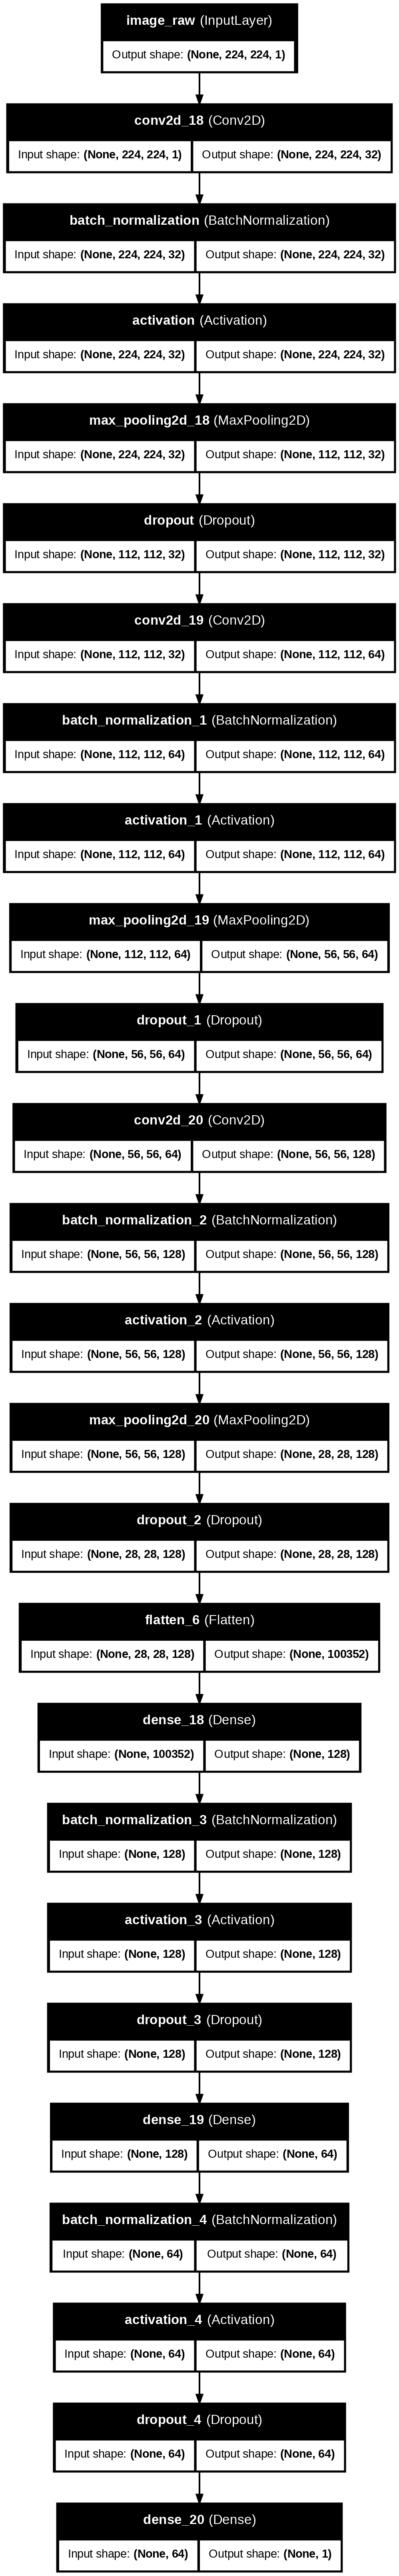

In [ ]:
def regularized_deep_model_structure():
    # Defining the input layer with a shape of (224, 224, 1)
    image_input = Input(shape=(224, 224, 1), name="image_raw")
    # Convolution layer: 32 filters, 3x3 kernel, same padding, l2 regularization of 0.01
    x = layers.Conv2D(32, (3, 3), padding="same", kernel_regularizer=regularizers.l2(0.01))(image_input)
    # Batch normalization to stabilization
    x = layers.BatchNormalization()(x)
    # ReLU activation function (non-linearity)
    x = layers.Activation("relu")(x)
    # Max pooling: pool size 2x2
    x = layers.MaxPooling2D((2, 2))(x)
    # Dropout of 0.3 to prevent overfitting
    x = layers.Dropout(0.3)(x)
    # Convolution layer: 64 filters, 3x3 kernel, same padding, l2 regularization of 0.01
    x = layers.Conv2D(64, (3, 3), padding="same", kernel_regularizer=regularizers.l2(0.01))(x)
    # Batch normalization to stabilization
    x = layers.BatchNormalization()(x)
    # ReLU activation function (non-linearity)
    x = layers.Activation("relu")(x)
    # Max pooling: pool size 2x2
    x = layers.MaxPooling2D((2, 2))(x)
    # Dropout of 0.4 to prevent overfitting
    x = layers.Dropout(0.4)(x)
    # Convolution layer: 128 filters, 3x3 kernel, same padding, l2 regularization of 0.01
    x = layers.Conv2D(128, (3, 3), padding="same", kernel_regularizer=regularizers.l2(0.01))(x)
    # Batch normalization to stabilization
    x = layers.BatchNormalization()(x)
    # ReLU activation function (non-linearity)
    x = layers.Activation("relu")(x)
    # Max pooling: pool size 2x2
    x = layers.MaxPooling2D((2, 2))(x)
    # Dropout of 0.5 to prevent overfitting
    x = layers.Dropout(0.5)(x)
    # Flatteningthe 2D feature maps to a vector for fully connected layers
    x = layers.Flatten()(x)
    # Fully connected layer: 128 neurons, l2 regularization of 0.01
    x = layers.Dense(128, kernel_regularizer=regularizers.l2(0.01))(x)
    # Batch normalization to stabilization
    x = layers.BatchNormalization()(x)
    # ReLU activation function (non-linearity)
    x = layers.Activation("relu")(x)
    # Dropout of 0.5 to prevent overfitting
    x = layers.Dropout(0.5)(x)
    # Fully connected layer: 64 neurons, l2 regularization of 0.01
    x = layers.Dense(64, kernel_regularizer=regularizers.l2(0.01))(x)
    # Batch normalization to stabilization
    x = layers.BatchNormalization()(x)
    # ReLU activation function (non-linearity)
    x = layers.Activation("relu")(x)
    # Dropout of 0.4 to prevent overfitting
    x = layers.Dropout(0.4)(x)
    # Output layer: 1 neuron with sigmoid activation to make binary classifications
    output = layers.Dense(1, activation="sigmoid")(x)
    # Creating the model with defined inputs and outputs
    model = models.Model(inputs=image_input, outputs=output)
    # Returning the built model
    return model

# Initializing the model
regularized_deep_model = regularized_deep_model_structure()
# Displaying the model architecture, including layer names, output shapes, and parameter counts
regularized_deep_model.summary()
# Plotting the model structure with input/output shapes for visualization
utils.plot_model(regularized_deep_model, to_file="regularized_deep_model_structure.png", show_shapes=True, show_layer_names=True, dpi=150)

In [ ]:
# Ensuring that the Fold directory exists
os.makedirs('/content/drive/MyDrive/Data/Data-Mini-Project/Fold/Regularized_Deep', exist_ok=True)

def fold_train_evaluation(fold,train_fold,val_fold):
  # Initializing the model
  regularized_deep_model = regularized_deep_model_structure()
  # Using a loss function that handles class imbalance like BinaryCrossentropy
  loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=False)
  # Compiling the model with appropriate loss function and optimizer
  regularized_deep_model.compile(optimizer="adam", loss=loss_fn, metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
  # Checkpoint callback to save the best model during training
  checkpoint_cb = ModelCheckpoint("/content/drive/MyDrive/Data/Data-Mini-Project/Fold/Regularized_Deep/regularized_deep_model_fold-"+str(fold)+".h5", save_best_only=True, monitor='val_auc', mode='max')
  # Early stopping callback to stop training if validation loss does not improve for 5 epochs
  early_stopping_cb = EarlyStopping(patience=5, restore_best_weights=True, monitor='val_auc')
  # Training the model
  train_fold = train_fold.map(lambda features, label: (features["image_raw"], label))
  val_fold = val_fold.map(lambda features, label: (features["image_raw"], label))
  regularized_deep_model_history = regularized_deep_model.fit(train_fold, validation_data=val_fold, epochs=30, callbacks=[checkpoint_cb, early_stopping_cb], class_weight = {0: 1.0, 1: (3366 / 717)})
  regularized_deep_model_history = regularized_deep_model_history.history
  # Storing the history in the pickle file
  with open('/content/drive/MyDrive/Data/Data-Mini-Project/Fold/Regularized_Deep/regularized_deep_model_history_fold-'+str(fold)+'.pkl', 'wb') as f:
    pickle.dump(regularized_deep_model_history, f)

# Generating the model for every fold
for fold in range(5):
  print(f"Fold {fold}")
  fold_train_evaluation(fold,fold_data[fold][0],fold_data[fold][1])

Fold 0
Epoch 1/30
     82/Unknown 22s 125ms/step - accuracy: 0.4656 - auc: 0.5246 - loss: 7.7789

82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 171ms/step - accuracy: 0.4658 - auc: 0.5249 - loss: 7.7777 - val_accuracy: 0.7645 - val_auc: 0.6440 - val_loss: 5.4405
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.5859 - auc: 0.6101 - loss: 5.6720 - val_accuracy: 0.7446 - val_auc: 0.6414 - val_loss: 4.0381
Epoch 3/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.5623 - auc: 0.5861 - loss: 4.3785 - val_accuracy: 0.3869 - val_auc: 0.6059 - val_loss: 3.3384
Epoch 4/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.5691 - auc: 0.5753 - loss: 3.7008 - val_accuracy: 0.1774 - val_auc: 0.6004 - val_loss: 3.6037
Epoch 5/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 21s 112ms/step - accuracy: 0.5939 - auc: 0.6120 - loss: 3.6957 - val_accuracy: 0.5520 - val_auc: 0.6229 - val_loss: 3.0783
Epoch 6/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6135 - auc: 0.6217 - loss: 3.5017

82/82 ━━━━━━━━━━━━━━━━━━━━ 23s 132ms/step - accuracy: 0.6135 - auc: 0.6217 - loss: 3.5010 - val_accuracy: 0.2171 - val_auc: 0.6556 - val_loss: 3.2355
Epoch 7/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6070 - auc: 0.5808 - loss: 3.3517

82/82 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.6069 - auc: 0.5810 - loss: 3.3509 - val_accuracy: 0.8242 - val_auc: 0.6819 - val_loss: 2.4454
Epoch 8/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - accuracy: 0.6339 - auc: 0.6394 - loss: 3.0451 - val_accuracy: 0.8211 - val_auc: 0.6316 - val_loss: 2.4599
Epoch 9/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - accuracy: 0.6271 - auc: 0.6441 - loss: 2.9650 - val_accuracy: 0.8303 - val_auc: 0.6499 - val_loss: 2.2185
Epoch 10/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.6413 - auc: 0.6570 - loss: 2.8158 - val_accuracy: 0.4709 - val_auc: 0.6088 - val_loss: 2.5672
Epoch 11/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6331 - auc: 0.6280 - loss: 3.0312

82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 137ms/step - accuracy: 0.6331 - auc: 0.6281 - loss: 3.0310 - val_accuracy: 0.2232 - val_auc: 0.7049 - val_loss: 2.7096
Epoch 12/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.6276 - auc: 0.6697 - loss: 2.7346 - val_accuracy: 0.4450 - val_auc: 0.6899 - val_loss: 2.3891
Epoch 13/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 20s 182ms/step - accuracy: 0.6468 - auc: 0.6628 - loss: 2.7148 - val_accuracy: 0.6422 - val_auc: 0.6879 - val_loss: 1.9739
Epoch 14/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.6234 - auc: 0.6316 - loss: 2.4795 - val_accuracy: 0.7217 - val_auc: 0.7016 - val_loss: 2.0069
Epoch 15/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.6413 - auc: 0.6609 - loss: 2.4460 - val_accuracy: 0.6820 - val_auc: 0.7005 - val_loss: 1.9253
Epoch 16/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.6682 - auc: 0.6800 - loss: 2.2463 - val_accuracy: 0.1896 - val_auc: 0.6535 - val_loss: 2.5259
Fold 1
Epoch 1/30
     82/Unknown 22s 137ms/ste

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 25s 165ms/step - accuracy: 0.5013 - auc: 0.5189 - loss: 7.3622 - val_accuracy: 0.5712 - val_auc: 0.6187 - val_loss: 4.8508
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6048 - auc: 0.6326 - loss: 4.8851

82/82 ━━━━━━━━━━━━━━━━━━━━ 30s 89ms/step - accuracy: 0.6047 - auc: 0.6323 - loss: 4.8812 - val_accuracy: 0.7611 - val_auc: 0.6209 - val_loss: 3.4142
Epoch 3/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.6360 - auc: 0.6511 - loss: 3.7390 - val_accuracy: 0.8254 - val_auc: 0.5943 - val_loss: 3.4681
Epoch 4/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.6086 - auc: 0.6401 - loss: 3.9932 - val_accuracy: 0.8132 - val_auc: 0.6166 - val_loss: 2.8017
Epoch 5/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 111ms/step - accuracy: 0.5905 - auc: 0.6163 - loss: 3.6874 - val_accuracy: 0.5375 - val_auc: 0.6046 - val_loss: 2.9531
Epoch 6/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 17s 60ms/step - accuracy: 0.6306 - auc: 0.6163 - loss: 3.4641 - val_accuracy: 0.8254 - val_auc: 0.5016 - val_loss: 2.2806
Epoch 7/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.6525 - auc: 0.6567 - loss: 2.9497 - val_accuracy: 0.4992 - val_auc: 0.6023 - val_loss: 2.7104
Fold 4
Epoch 1/30
     82/Unknown 20s 115ms/step 

82/82 ━━━━━━━━━━━━━━━━━━━━ 23s 153ms/step - accuracy: 0.4880 - auc: 0.5307 - loss: 7.8383 - val_accuracy: 0.4181 - val_auc: 0.6106 - val_loss: 6.7419
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5873 - auc: 0.6296 - loss: 6.0293

82/82 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.5873 - auc: 0.6295 - loss: 6.0224 - val_accuracy: 0.8285 - val_auc: 0.6820 - val_loss: 4.0219
Epoch 3/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.6330 - auc: 0.6117 - loss: 4.4541 - val_accuracy: 0.4609 - val_auc: 0.6375 - val_loss: 3.7833
Epoch 4/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.6045 - auc: 0.6163 - loss: 3.9685 - val_accuracy: 0.2588 - val_auc: 0.5713 - val_loss: 3.2273
Epoch 5/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.6260 - auc: 0.6428 - loss: 3.2058 - val_accuracy: 0.6064 - val_auc: 0.6300 - val_loss: 2.8743
Epoch 6/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6148 - auc: 0.6384 - loss: 3.1816

82/82 ━━━━━━━━━━━━━━━━━━━━ 23s 208ms/step - accuracy: 0.6147 - auc: 0.6382 - loss: 3.1811 - val_accuracy: 0.8254 - val_auc: 0.6929 - val_loss: 2.5098
Epoch 7/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.6372 - auc: 0.6232 - loss: 3.0704 - val_accuracy: 0.7825 - val_auc: 0.6397 - val_loss: 2.4893
Epoch 8/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.5971 - auc: 0.5987 - loss: 2.9405 - val_accuracy: 0.8254 - val_auc: 0.6664 - val_loss: 2.0030
Epoch 9/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.6624 - auc: 0.6422 - loss: 2.6608 - val_accuracy: 0.4931 - val_auc: 0.6542 - val_loss: 2.2852
Epoch 10/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.6645 - auc: 0.6430 - loss: 2.5775 - val_accuracy: 0.8254 - val_auc: 0.5818 - val_loss: 1.9615
Epoch 11/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.6600 - auc: 0.6454 - loss: 2.5404 - val_accuracy: 0.3093 - val_auc: 0.5970 - val_loss: 2.6133


In [ ]:
roc_auc_values=[]
# For each model
for fold in range(5):
  # Loading the models
  with open('/content/drive/MyDrive/Data/Data-Mini-Project/Fold/Regularized_Deep/regularized_deep_model_history_fold-'+str(fold)+'.pkl', 'rb') as f:
    regularized_deep_model_history = pickle.load(f)
  # Extracting the selected model's roc auc
  roc_auc = max(regularized_deep_model_history['val_auc'])
  roc_auc_values.append(roc_auc)
  print(f"Fold {fold} ROC AUC: {roc_auc}")

# Selecting the model having the highest roc auc
best_model_index = roc_auc_values.index(max(roc_auc_values))
print(f"Best Model: Fold {best_model_index}")
# Loading the best model
regularized_deep_model = tf.keras.models.load_model("/content/drive/MyDrive/Data/Data-Mini-Project/Fold/Regularized_Deep/regularized_deep_model_fold-"+str(best_model_index)+".h5")
# Loading the best model history
with open('/content/drive/MyDrive/Data/Data-Mini-Project/Fold/Regularized_Deep/regularized_deep_model_history_fold-'+str(best_model_index)+'.pkl', 'rb') as f:
  regularized_deep_model_history = pickle.load(f)

Fold 0 ROC AUC: 0.7049124240875244
Fold 1 ROC AUC: 0.7105181217193604
Fold 2 ROC AUC: 0.7134798765182495
Fold 3 ROC AUC: 0.6208502054214478
Fold 4 ROC AUC: 0.6929287314414978
Best Model: Fold 2


In [ ]:
test_img = test.map(lambda features, label: (features["image_raw"], label))
test_loss, test_accuracy, test_auc = regularized_deep_model.evaluate(test_img)
print(f"Fold {fold} - Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, Test AUC: {test_auc:.4f}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.7483 - auc: 0.6588 - loss: 2.8724
Fold 4 - Test Loss: 2.8653, Test Accuracy: 0.7687, Test AUC: 0.6887


# Creating and testing an advanced model

Model: "functional_48"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ image_raw (InputLayer)    │ (None, 224, 224, 1)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_138 (Conv2D)       │ (None, 224, 224, 32)   │            320 │ image_raw[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_274   │ (None, 224, 224, 32)   │            128 │ conv2d_138[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_274            │ (None, 224, 224, 32)   │              0 │ batch_normalization_2… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_138         │ (None, 112, 112, 32)   │              0 │ activation_274[0][0]   │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_274 (Dropout)     │ (None, 112, 112, 32)   │              0 │ max_pooling2d_138[0][… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_139 (Conv2D)       │ (None, 112, 112, 64)   │         18,496 │ dropout_274[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_275   │ (None, 112, 112, 64)   │            256 │ conv2d_139[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_275            │ (None, 112, 112, 64)   │              0 │ batch_normalization_2… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_139         │ (None, 56, 56, 64)     │              0 │ activation_275[0][0]   │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_275 (Dropout)     │ (None, 56, 56, 64)     │              0 │ max_pooling2d_139[0][… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_140 (Conv2D)       │ (None, 56, 56, 128)    │         73,856 │ dropout_275[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_276   │ (None, 56, 56, 128)    │            512 │ conv2d_140[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ tabular_input             │ (None, 3)              │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_276            │ (None, 56, 56, 128)    │              0 │ batch_normalization_2… │
│ (Activation)              │                        │                │                        │
├──────────────────────

 Total params: 12,950,689 (49.40 MB)

 Trainable params: 12,949,761 (49.40 MB)

 Non-trainable params: 928 (3.62 KB)

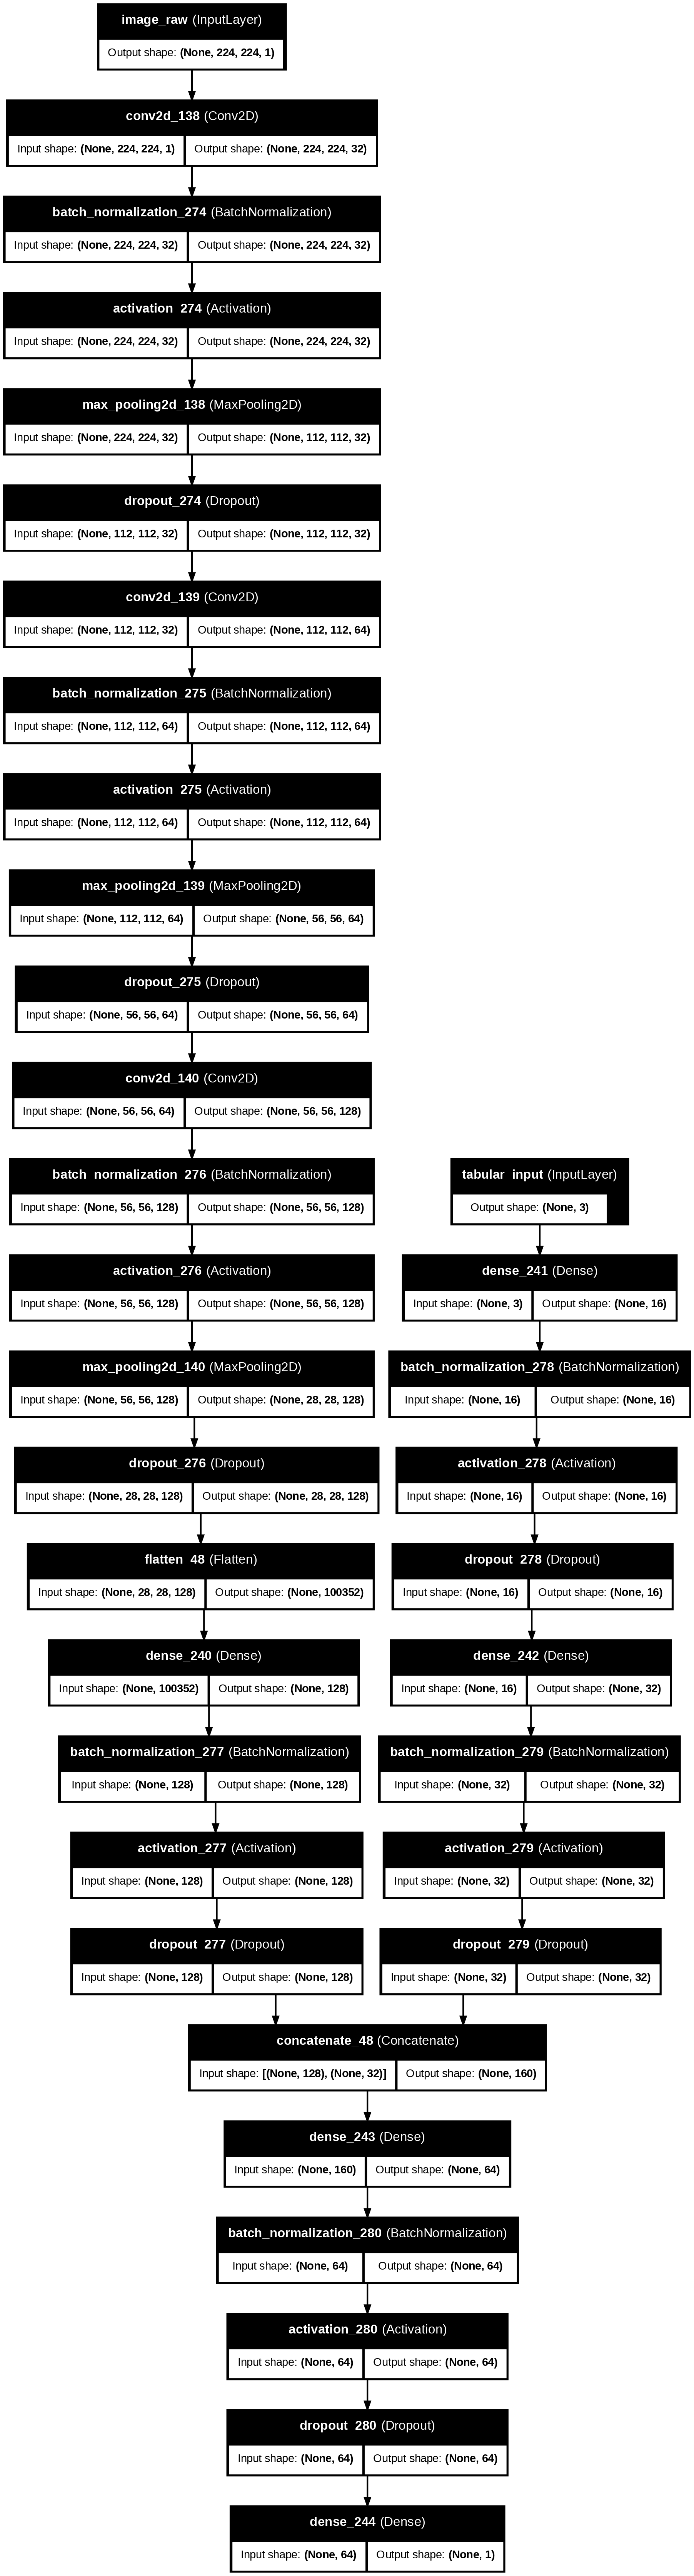

In [ ]:
def advanced_model_structure():
    # Defining the input layer with a shape of (224, 224, 1)
    image_input = Input(shape=(224, 224, 1), name="image_raw")
    # Convolution layer: 32 filters, 3x3 kernel, same padding, l2 regularization of 0.01
    x = layers.Conv2D(32, (3, 3), padding="same", kernel_regularizer=regularizers.l2(0.01))(image_input)
    # Batch normalization to stabilization
    x = layers.BatchNormalization()(x)
    # ReLU activation function (non-linearity)
    x = layers.Activation("relu")(x)
    # Max pooling: pool size 2x2
    x = layers.MaxPooling2D((2, 2))(x)
    # Dropout of 0.3 to prevent overfitting
    x = layers.Dropout(0.3)(x)
    # Convolution layer: 64 filters, 3x3 kernel, same padding, l2 regularization of 0.01
    x = layers.Conv2D(64, (3, 3), padding="same", kernel_regularizer=regularizers.l2(0.01))(x)
    # Batch normalization to stabilization
    x = layers.BatchNormalization()(x)
    # ReLU activation function (non-linearity)
    x = layers.Activation("relu")(x)
    # Max pooling: pool size 2x2
    x = layers.MaxPooling2D((2, 2))(x)
    # Dropout of 0.4 to prevent overfitting
    x = layers.Dropout(0.4)(x)
    # Convolution layer: 128 filters, 3x3 kernel, same padding, l2 regularization of 0.01
    x = layers.Conv2D(128, (3, 3), padding="same", kernel_regularizer=regularizers.l2(0.01))(x)
    # Batch normalization to stabilization
    x = layers.BatchNormalization()(x)
    # ReLU activation function (non-linearity)
    x = layers.Activation("relu")(x)
    # Max pooling: pool size 2x2
    x = layers.MaxPooling2D((2, 2))(x)
    # Dropout of 0.5 to prevent overfitting
    x = layers.Dropout(0.5)(x)
    # Flatteningthe 2D feature maps to a vector for fully connected layers
    x = layers.Flatten()(x)
    # Fully connected layer: 128 neurons, l2 regularization of 0.01
    x = layers.Dense(128, kernel_regularizer=regularizers.l2(0.01))(x)
    # Batch normalization to stabilization
    x = layers.BatchNormalization()(x)
    # ReLU activation function (non-linearity)
    x = layers.Activation("relu")(x)
    # Dropout of 0.5 to prevent overfitting
    x = layers.Dropout(0.5)(x)
    # Defining the input layer for tabular features (body_part, angles, hardware) of shape (3,)
    tabular_input = Input(shape=(3,), name="tabular_input")
    # Fully connected layer: 16 neurons, l2 regularization of 0.01
    y = layers.Dense(16, kernel_regularizer=regularizers.l2(0.01))(tabular_input)
    # Batch normalization to stabilization
    y = layers.BatchNormalization()(y)
    # ReLU activation function (non-linearity)
    y = layers.Activation("relu")(y)
    # Dropout of 0.2 to prevent overfitting
    y = layers.Dropout(0.2)(y)
    # Fully connected layer: 32 neurons, l2 regularization of 0.01
    y = layers.Dense(32, kernel_regularizer=regularizers.l2(0.01))(y)
    # Batch normalization to stabilization
    y = layers.BatchNormalization()(y)
    # ReLU activation function (non-linearity)
    y = layers.Activation("relu")(y)
    # Dropout of 0.3 to prevent overfitting
    y = layers.Dropout(0.3)(y)
    # Concatenating the flattened image features and tabular features
    combined = layers.concatenate([x, y])
    # Fully connected layer: 64 neurons, l2 regularization of 0.01
    z = layers.Dense(64, kernel_regularizer=regularizers.l2(0.01))(combined)
    # Batch normalization to stabilization
    z = layers.BatchNormalization()(z)
    # ReLU activation function (non-linearity)
    z = layers.Activation("relu")(z)
    # Dropout of 0.4 to prevent overfitting
    z = layers.Dropout(0.4)(z)
    # Output layer: 1 neuron with sigmoid activation to make binary classifications
    output = layers.Dense(1, activation="sigmoid")(z)
    # Creating the model with defined inputs and outputs
    model = models.Model(inputs=[image_input, tabular_input], outputs=output)
    # Returning the built model
    return model

# Initializing the model
advanced_model = advanced_model_structure()
# Displaying the model architecture, including layer names, output shapes, and parameter counts
advanced_model.summary()
# Plotting the model structure with input/output shapes for visualization
utils.plot_model(advanced_model, to_file="advanced_model_structure.png", show_shapes=True, show_layer_names=True, dpi=150)

In [ ]:
# Ensuring that the Fold directory exists
os.makedirs('/content/drive/MyDrive/Data/Data-Mini-Project/Fold/Advanced', exist_ok=True)

def fold_train_evaluation(fold,train_fold,val_fold):
  # Initializing the model
  advanced_model = advanced_model_structure()
  # Using a loss function that handles class imbalance like BinaryCrossentropy
  loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=False)
  # Compiling the model with appropriate loss function and optimizer
  advanced_model.compile(optimizer="adam", loss=loss_fn, metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
  # Checkpoint callback to save the best model during training
  checkpoint_cb = ModelCheckpoint("/content/drive/MyDrive/Data/Data-Mini-Project/Fold/Advanced/advanced_model_fold-"+str(fold)+".h5", save_best_only=True, monitor='val_auc', mode='max')
  # Early stopping callback to stop training if validation loss does not improve for 5 epochs
  early_stopping_cb = EarlyStopping(patience=5, restore_best_weights=True, monitor='val_auc')
  # Training the model
  advanced_model_history = advanced_model.fit(train_fold, validation_data=val_fold, epochs=30, callbacks=[checkpoint_cb, early_stopping_cb], class_weight = {0: 1.0, 1: (3366 / 717)})
  advanced_model_history = advanced_model_history.history
  # Storing the history in the pickle file
  with open('/content/drive/MyDrive/Data/Data-Mini-Project/Fold/Advanced/advanced_model_history_fold-'+str(fold)+'.pkl', 'wb') as f:
    pickle.dump(advanced_model_history, f)

# Generating the model for every fold
for fold in range(5):
  print(f"Fold {fold}")
  fold_train_evaluation(fold,fold_data[fold][0],fold_data[fold][1])

Fold 0
Epoch 1/30
     82/Unknown 26s 144ms/step - accuracy: 0.4980 - auc: 0.5126 - loss: 7.7750

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


82/82 ━━━━━━━━━━━━━━━━━━━━ 50s 435ms/step - accuracy: 0.4985 - auc: 0.5133 - loss: 7.7695 - val_accuracy: 0.2508 - val_auc: 0.6300 - val_loss: 5.0357
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6346 - auc: 0.7048 - loss: 4.6932

82/82 ━━━━━━━━━━━━━━━━━━━━ 19s 220ms/step - accuracy: 0.6345 - auc: 0.7045 - loss: 4.6892 - val_accuracy: 0.7691 - val_auc: 0.6321 - val_loss: 3.5460
Epoch 3/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6075 - auc: 0.6665 - loss: 4.0486

82/82 ━━━━━━━━━━━━━━━━━━━━ 20s 219ms/step - accuracy: 0.6075 - auc: 0.6664 - loss: 4.0472 - val_accuracy: 0.5352 - val_auc: 0.7596 - val_loss: 3.2812
Epoch 4/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6121 - auc: 0.6694 - loss: 3.8341

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 77s 764ms/step - accuracy: 0.5452 - auc: 0.5677 - loss: 7.7504 - val_accuracy: 0.7381 - val_auc: 0.7205 - val_loss: 5.2157
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.6279 - auc: 0.6927 - loss: 5.1107 - val_accuracy: 0.3384 - val_auc: 0.5862 - val_loss: 4.1911
Epoch 3/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.6374 - auc: 0.6551 - loss: 4.0451 - val_accuracy: 0.2006 - val_auc: 0.6944 - val_loss: 3.8266
Epoch 4/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6418 - auc: 0.7124 - loss: 3.5243

82/82 ━━━━━━━━━━━━━━━━━━━━ 65s 744ms/step - accuracy: 0.6419 - auc: 0.7125 - loss: 3.5226 - val_accuracy: 0.7703 - val_auc: 0.7227 - val_loss: 2.6337
Epoch 5/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6334 - auc: 0.6924 - loss: 3.1510

82/82 ━━━━━━━━━━━━━━━━━━━━ 83s 761ms/step - accuracy: 0.6336 - auc: 0.6926 - loss: 3.1504 - val_accuracy: 0.8361 - val_auc: 0.7624 - val_loss: 2.3614
Epoch 6/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.6756 - auc: 0.7237 - loss: 2.9837 - val_accuracy: 0.8070 - val_auc: 0.7614 - val_loss: 2.7698
Epoch 7/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.6549 - auc: 0.7093 - loss: 3.3087 - val_accuracy: 0.7228 - val_auc: 0.7524 - val_loss: 2.9186
Epoch 8/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6703 - auc: 0.7300 - loss: 3.1522

82/82 ━━━━━━━━━━━━━━━━━━━━ 56s 679ms/step - accuracy: 0.6704 - auc: 0.7301 - loss: 3.1506 - val_accuracy: 0.7979 - val_auc: 0.7963 - val_loss: 2.3114
Epoch 9/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 32s 60ms/step - accuracy: 0.6634 - auc: 0.7300 - loss: 2.8315 - val_accuracy: 0.8025 - val_auc: 0.7768 - val_loss: 2.0967
Epoch 10/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.6767 - auc: 0.7204 - loss: 2.6795 - val_accuracy: 0.6830 - val_auc: 0.7715 - val_loss: 2.4864
Epoch 11/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.6731 - auc: 0.7356 - loss: 2.7102 - val_accuracy: 0.7397 - val_auc: 0.7705 - val_loss: 1.8134
Epoch 12/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6605 - auc: 0.7276 - loss: 2.4967

82/82 ━━━━━━━━━━━━━━━━━━━━ 66s 749ms/step - accuracy: 0.6606 - auc: 0.7278 - loss: 2.4976 - val_accuracy: 0.5942 - val_auc: 0.7970 - val_loss: 2.4277
Epoch 13/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 304ms/step - accuracy: 0.6768 - auc: 0.7560 - loss: 2.4807 - val_accuracy: 0.5237 - val_auc: 0.7623 - val_loss: 2.1056
Epoch 14/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.6551 - auc: 0.7391 - loss: 2.2818 - val_accuracy: 0.6723 - val_auc: 0.7605 - val_loss: 1.6585
Epoch 15/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.6675 - auc: 0.7392 - loss: 2.1389 - val_accuracy: 0.6738 - val_auc: 0.7863 - val_loss: 1.8096
Epoch 16/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.6692 - auc: 0.7352 - loss: 2.2361 - val_accuracy: 0.2251 - val_auc: 0.7366 - val_loss: 2.2245
Epoch 17/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.6648 - auc: 0.7376 - loss: 2.2527 - val_accuracy: 0.7351 - val_auc: 0.7543 - val_loss: 1.7286


In [ ]:
roc_auc_values=[]
# For each model
for fold in range(5):
  # Loading the models
  with open('/content/drive/MyDrive/Data/Data-Mini-Project/Fold/Advanced/advanced_model_history_fold-'+str(fold)+'.pkl', 'rb') as f:
    advanced_model_history = pickle.load(f)
  # Extracting the selected model's roc auc
  roc_auc = max(advanced_model_history['val_auc'])
  roc_auc_values.append(roc_auc)
  print(f"Fold {fold} ROC AUC: {roc_auc}")

# Selecting the model having the highest roc auc
best_model_index = roc_auc_values.index(max(roc_auc_values))
print(f"Best Model: Fold {best_model_index}")
# Loading the best model
advanced_model = tf.keras.models.load_model("/content/drive/MyDrive/Data/Data-Mini-Project/Fold/Advanced/advanced_model_fold-"+str(best_model_index)+".h5")
# Loading the best model history
with open('/content/drive/MyDrive/Data/Data-Mini-Project/Fold/Advanced/advanced_model_history_fold-'+str(best_model_index)+'.pkl', 'rb') as f:
  advanced_model_history = pickle.load(f)


Fold 0 ROC AUC: 0.7786964774131775
Fold 1 ROC AUC: 0.7811574935913086
Fold 2 ROC AUC: 0.7794165015220642
Fold 3 ROC AUC: 0.6845401525497437
Fold 4 ROC AUC: 0.7879586219787598
Best Model: Fold 4


In [ ]:
test_loss, test_accuracy, test_auc = advanced_model.evaluate(test)
print(f"Fold {fold} - Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, Test AUC: {test_auc:.4f}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.8002 - auc: 0.7911 - loss: 1.9473
Fold 4 - Test Loss: 1.9460, Test Accuracy: 0.7882, Test AUC: 0.7917


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


# Comparative analysis

### Generating the predictions and extracting the actual labels

In [ ]:
# Generating the prediction probabilities and the actual labels over the test data using the simple model
print("Predicting using the simple model")
simple_model_pred_prob = []
simple_model_actual_labels = []
for features, labels in test_img:
  preds = simple_model.predict(features)
  simple_model_actual_labels.extend(labels.numpy())
  simple_model_pred_prob.extend(preds.ravel())

# Generating the prediction probabilities and the actual labels over the test data using the deep model
print("Predicting using the deep model")
deep_model_pred_prob = []
deep_model_actual_labels = []
for features, labels in test_img:
  preds = deep_model.predict(features)
  deep_model_actual_labels.extend(labels.numpy())
  deep_model_pred_prob.extend(preds.ravel())

# Generating the prediction probabilities and the actual labels over the test data using the regularized deep model
print("Predicting using the regularized deep model")
regularized_deep_model_pred_prob = []
regularized_deep_model_actual_labels = []
for features, labels in test_img:
  preds = regularized_deep_model.predict(features)
  regularized_deep_model_actual_labels.extend(labels.numpy())
  regularized_deep_model_pred_prob.extend(preds.ravel())

# Generating the prediction probabilities and the actual labels over the test data using the advanced model
print("Predicting using the advanced model")
advanced_model_pred_prob = []
advanced_model_actual_labels = []
for features, labels in test:
  preds = advanced_model.predict(features)
  advanced_model_actual_labels.extend(labels.numpy())
  advanced_model_pred_prob.extend(preds.ravel())

# Converting the predicted probabilities to predictions (threshold = 0.5)
simple_model_pred = np.array(simple_model_pred_prob) > 0.5
deep_model_pred = np.array(deep_model_pred_prob) > 0.5
regularized_deep_model_pred = np.array(regularized_deep_model_pred_prob) > 0.5
advanced_model_pred = np.array(advanced_model_pred_prob) > 0.5

Predicting using the simple model
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 501ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 534ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30

### Displaying the model evaluation metrics

In [ ]:
def model_metrics(actual_labels, model_pred_prob, model_pred):
  # Calculate the confusion matrix
  tn, fp, fn, tp = confusion_matrix(actual_labels, model_pred).ravel()
  # Accuracy
  accuracy = (tp + tn) / (tp + tn + fp + fn)
  # Precision
  precision = tp / (tp + fp) if (tp + fp) != 0 else 0
  # Sensitivity / Recall
  sensitivity = tp / (tp + fn) if (tp + fn) != 0 else 0
  # Specificity
  specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
  # Negative Predictive Value (NPV)
  npv = tn / (tn + fn) if (tn + fn) != 0 else 0
  # F1 Score
  f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) != 0 else 0
  # ROC AUC
  roc_auc = roc_auc_score(actual_labels, model_pred_prob)
  # returning the values
  return [accuracy, precision, sensitivity, specificity, npv, f1, roc_auc]

# Collecting metrics for all models
model_results = []
# Calculating metrics for each model
model_results.append(model_metrics(simple_model_actual_labels, simple_model_pred_prob, simple_model_pred))
model_results.append(model_metrics(deep_model_actual_labels, deep_model_pred_prob, deep_model_pred))
model_results.append(model_metrics(regularized_deep_model_actual_labels, regularized_deep_model_pred_prob, regularized_deep_model_pred))
model_results.append(model_metrics(advanced_model_actual_labels, advanced_model_pred_prob, advanced_model_pred))
# Converting to a tabular format
model_names = ['Simple Model', 'Deep Model', 'Regularized Deep Model', 'Advanced Model']
# Initializing PrettyTable object
table = PrettyTable()
# Setting the column names
table.field_names = ["Model", "Accuracy", "Precision", "Sensitivity", "Specificity", "NPV", "F1 Score", "ROC AUC"]
# Adding the rows for each model
for i, model_name in enumerate(model_names):
    table.add_row([model_name] + model_results[i])
# Printing the table
print(table)

+------------------------+--------------------+---------------------+--------------------+--------------------+--------------------+---------------------+--------------------+
|         Model          |      Accuracy      |      Precision      |    Sensitivity     |    Specificity     |        NPV         |       F1 Score      |      ROC AUC       |
+------------------------+--------------------+---------------------+--------------------+--------------------+--------------------+---------------------+--------------------+
|      Simple Model      | 0.609547123623011  | 0.25956284153005466 | 0.6643356643356644 | 0.5979228486646885 | 0.893569844789357  |  0.3732809430255403 | 0.6851590545952564 |
|       Deep Model       | 0.6940024479804161 |  0.3025830258302583 | 0.5734265734265734 | 0.7195845697329377 | 0.8882783882783882 | 0.39613526570048313 | 0.7128613226536076 |
| Regularized Deep Model | 0.7686658506731946 |  0.3380281690140845 | 0.3356643356643357 | 0.8605341246290801 | 0.859259

### Visualizing the loss values

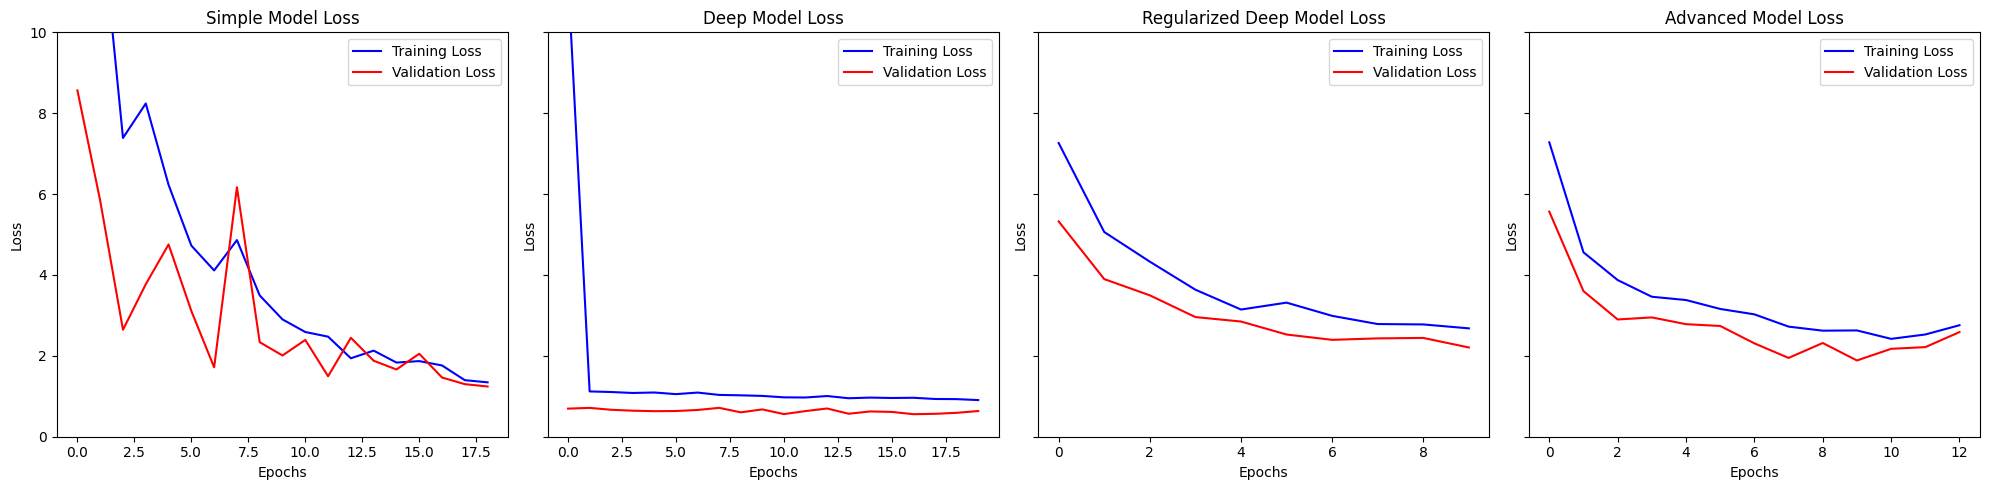

In [ ]:
# List of the history of all the models
model_histories = [simple_model_history, deep_model_history, regularized_deep_model_history, advanced_model_history]
# List of model names
model_names = ['Simple Model', 'Deep Model', 'Regularized Deep Model', 'Advanced Model']

# Creating a figure with 4 subplots (horizontally) that share the y axis
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
# Looping through the model histories and plotting their training/validation loss
for i, model_history in enumerate(model_histories):
  ax = axes[i]
  # Extracting the training and validation loss
  train_loss = model_history['loss']
  val_loss = model_history['val_loss']
  # Plotting the training and validation loss
  ax.plot(train_loss, label='Training Loss', color='blue')
  ax.plot(val_loss, label='Validation Loss', color='red')
  # Setting the labels and title
  ax.set_title(f'{model_names[i]} Loss')
  ax.set_xlabel('Epochs')
  ax.set_ylabel('Loss')
  # Displaying the legend
  ax.legend()
  # Setting the y-axis limits from 0 to 10
  ax.set_ylim(0, 10)
# Displaying the plot
plt.tight_layout()
plt.show()

### Visualizing the accuracy values

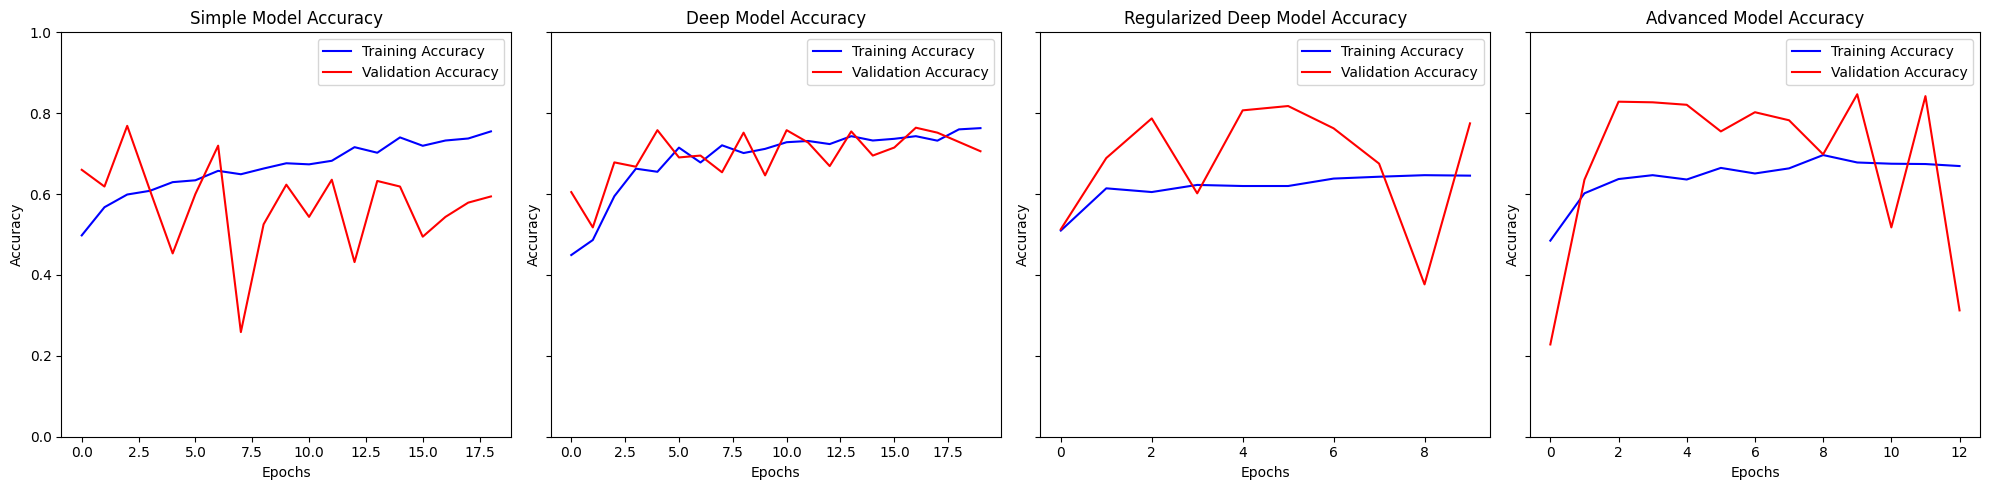

In [ ]:
# Creating a figure with 4 subplots (horizontally) that share the y axis
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
# Looping through the model histories and plotting their training and validation accuracies
for i, model_history in enumerate(model_histories):
  ax = axes[i]
  # Extracting training accuracy
  train_accuracy = model_history['accuracy']
  # Extracting validation accuracy
  val_accuracy = model_history['val_accuracy']
  # Plotting the training and validation accuracy
  ax.plot(train_accuracy, label='Training Accuracy', color='blue')
  ax.plot(val_accuracy, label='Validation Accuracy', color='red')
  # Setting the labels and title
  ax.set_title(f'{model_names[i]} Accuracy')
  ax.set_xlabel('Epochs')
  ax.set_ylabel('Accuracy')
  # Displaying the legend
  ax.legend()
  # Setting the y-axis limits from 0 to 10
  ax.set_ylim(0, 1)
# Displaying the plot
plt.tight_layout()
plt.show()

### Visualizing the ROC curve

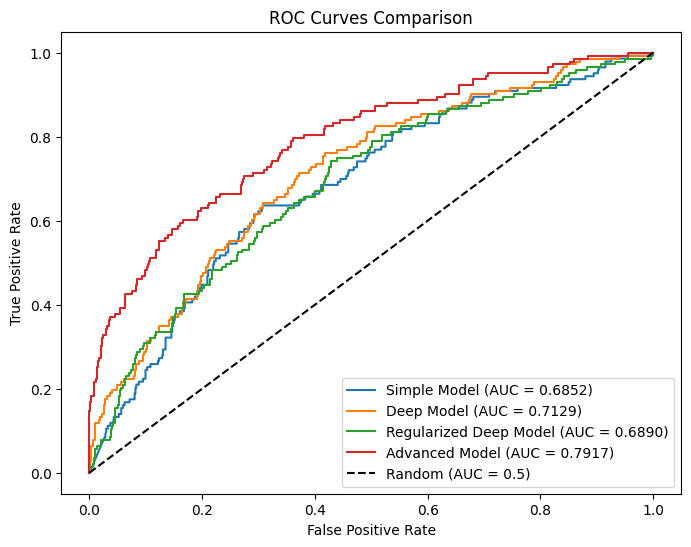

In [ ]:
# Defining a function to calculate the fpr, tpr and the auc
def plot_roc_curve(actual_labels, model_pred_prob):
    # Calculating the fpr and tpr
    fpr, tpr, thresholds = roc_curve(actual_labels, model_pred_prob)
    # Computing the AUC score
    auc = roc_auc_score(actual_labels, model_pred_prob)
    # Returning the values
    return fpr, tpr, auc

# Creating the plot
plt.figure(figsize=(8, 6))
# Plotting the simple model's roc
fpr, tpr, auc = plot_roc_curve(simple_model_actual_labels, simple_model_pred_prob)
plt.plot(fpr, tpr, label=f'Simple Model (AUC = {auc:.4f})')
# Plotting the deep model's roc
fpr, tpr, auc = plot_roc_curve(deep_model_actual_labels, deep_model_pred_prob)
plt.plot(fpr, tpr, label=f'Deep Model (AUC = {auc:.4f})')
# Plotting the regularized deep model's roc
fpr, tpr, auc = plot_roc_curve(regularized_deep_model_actual_labels, regularized_deep_model_pred_prob)
plt.plot(fpr, tpr, label=f'Regularized Deep Model (AUC = {auc:.4f})')
# Plotting the advanced model's roc
fpr, tpr, auc = plot_roc_curve(advanced_model_actual_labels, advanced_model_pred_prob)
plt.plot(fpr, tpr, label=f'Advanced Model (AUC = {auc:.4f})')
# Plot the diagonal depicting a model that randomly guesses
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Random (AUC = 0.5)')
# Setting the labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
# Displaying the legend
plt.legend(loc='lower right')
# Displaying the plot
plt.show()